In [1]:
import os
import pandas as pd
import pickle
import ast
import torch

### Root to save csvs

In [2]:
root_save_dir = "CUB_analysis_csv"

In [3]:
# Build up CUB dataframe
splits_pkl = ["train.pkl", "val.pkl", "test.pkl"]

root_cbm = os.path.join("datasets", "CUB", "class_attr_data_10")

df_cub = pd.DataFrame()

for split in splits_pkl:
    split_path = os.path.join(root_cbm, split)
    # list of dictionaries, each dictionary is a row in the dataframe
    pkl_data = pd.read_pickle(split_path)
    df_split = pd.DataFrame(pkl_data)
    df_cub = pd.concat([df_cub, df_split], ignore_index=True)
    
    
df_cub.head(10)

,id,img_path,class_label,attribute_label,attribute_certainty
0,1210,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,21,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
1,2987,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,51,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
2,3621,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,62,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, ..."
3,9938,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,168,"[0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, ..."
4,41,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
5,4097,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,70,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, ..."
6,1366,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,24,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
7,5878,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,100,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
8,5631,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,96,"[0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
9,7426,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,126,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, ..."


## Class idx to class name

In [4]:
# Count how many unique bird species are in each split
for split in splits_pkl:
    split_path = os.path.join(root_cbm, split)
    pkl_data = pd.read_pickle(split_path)
    df_split = pd.DataFrame(pkl_data)
    num_unique_species = df_split["class_label"].nunique()
    max_class_label = df_split["class_label"].max()
    min_class_label = df_split["class_label"].min()
    # get range 
    print(f"Split: {split}, Number of unique species: {num_unique_species}, Range: {min_class_label} - {max_class_label}")

Split: train.pkl, Number of unique species: 200, Range: 0 - 199
Split: val.pkl, Number of unique species: 200, Range: 0 - 199
Split: test.pkl, Number of unique species: 200, Range: 0 - 199


In [5]:
class_names = pd.read_csv(os.path.join("datasets", "CUB/CUB_200_2011//CUB_200_2011/classes.txt"), sep=" ", header=None, names=["class_id", "class_name"])
# 0 index the class_idx
class_names["class_id"] = class_names["class_id"] - 1



## 112 Concepts

In [6]:


ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]




def get_attribute_parts_to_indices():
    """
    Maps attribute idx to attribute parts (e.g. bill, wing, etc.)
    """
    
    
    # Attribute idx in the original 312 attribute space to attribute idx in the new 112 attribute space
    old_idx_to_new_idx = {old_idx: new_idx for new_idx, old_idx in enumerate(ATTRIBUTES_IDX_USED)}
    #print(old_idx_to_new_idx)
    

    path_attrubute_file = os.path.join("datasets", "CUB/CUB_200_2011/attributes.txt")



    with open(path_attrubute_file, "r") as f:
        lines = f.readlines()
        semantic_groups = {}
        for line in lines:
            idx, attr_name = line.strip().split(" ")
            idx = int(idx) - 1 # Convert to 0-based index
            if idx not in ATTRIBUTES_IDX_USED:
                continue
                
            new_idx = old_idx_to_new_idx[idx]
            semantic_group = attr_name.split("::")[0]
            if semantic_group not in semantic_groups:
                semantic_groups[semantic_group] = []
            semantic_groups[semantic_group].append(new_idx)

        return semantic_groups
    

get_attribute_parts_to_indices()

{'has_bill_shape': [0, 1, 2, 3],
 'has_wing_color': [4, 5, 6, 7, 8, 9],
 'has_upperparts_color': [10, 11, 12, 13, 14, 15],
 'has_underparts_color': [16, 17, 18, 19, 20, 21],
 'has_breast_pattern': [22, 23, 24],
 'has_back_color': [25, 26, 27, 28, 29, 30],
 'has_tail_shape': [31],
 'has_upper_tail_color': [32, 33, 34, 35, 36],
 'has_head_pattern': [37, 38],
 'has_breast_color': [39, 40, 41, 42, 43, 44],
 'has_throat_color': [45, 46, 47, 48, 49],
 'has_eye_color': [50],
 'has_bill_length': [51, 52],
 'has_forehead_color': [53, 54, 55, 56, 57, 58],
 'has_under_tail_color': [59, 60, 61, 62, 63],
 'has_nape_color': [64, 65, 66, 67, 68, 69],
 'has_belly_color': [70, 71, 72, 73, 74, 75],
 'has_wing_shape': [76, 77],
 'has_size': [78, 79, 80],
 'has_shape': [81, 82],
 'has_back_pattern': [83, 84, 85],
 'has_tail_pattern': [86, 87, 88],
 'has_belly_pattern': [89],
 'has_primary_color': [90, 91, 92, 93, 94, 95],
 'has_leg_color': [96, 97, 98],
 'has_bill_color': [99, 100, 101],
 'has_crown_color

In [7]:
def get_attribute_names():
    """
    Maps attribute idx to attribute names
    """
    
    # Attribute idx in the original 312 attribute space to attribute idx in the new 112 attribute space
    old_idx_to_new_idx = {old_idx: new_idx for new_idx, old_idx in enumerate(ATTRIBUTES_IDX_USED)}
    #print(old_idx_to_new_idx)
    

    path_attrubute_file = os.path.join("datasets", "CUB/CUB_200_2011/attributes.txt")



    with open(path_attrubute_file, "r") as f:
        lines = f.readlines()
        attribute_names = {}
        for line in lines:
            idx, attr_name = line.strip().split(" ")
            idx = int(idx) - 1 # Convert to 0-based index
            if idx not in ATTRIBUTES_IDX_USED:
                continue
                
            new_idx = old_idx_to_new_idx[idx]
            attribute_names[new_idx] = attr_name

        return attribute_names
    
attr_idx_to_names = get_attribute_names()

df_attr_idx_to_names = pd.DataFrame(list(attr_idx_to_names.items()), columns=["idx", "name"])
df_attr_idx_to_names.to_csv(os.path.join(root_save_dir, "112_concepts.csv"), index=False)
df_attr_idx_to_names.head(10)



,idx,name
0,0,has_bill_shape::dagger
1,1,has_bill_shape::hooked_seabird
2,2,has_bill_shape::all-purpose
3,3,has_bill_shape::cone
4,4,has_wing_color::brown
5,5,has_wing_color::grey
6,6,has_wing_color::yellow
7,7,has_wing_color::black
8,8,has_wing_color::white
9,9,has_wing_color::buff


## Dataset with samples and attributes

In [8]:
# From df_cub expand with attribute names and for each sample 0 or 1 for each attribute
attr_names = [attr_idx_to_names[i] for i in range(len(attr_idx_to_names))]

df_attrs = pd.DataFrame(
    df_cub["attribute_label"].tolist(),
    columns=attr_names,
    index=df_cub.index,
    dtype="int8",
)

df_samples = pd.concat([df_cub[["id", "class_label"]], df_attrs], axis=1)

# Add class_name as well
class_id_to_name = dict(zip(class_names["class_id"], class_names["class_name"]))
df_samples.insert(2, "class_name", df_samples["class_label"].map(class_id_to_name))
assert df_samples["class_name"].notna().all()

df_samples.to_csv(os.path.join(root_save_dir, "samples_attributes.csv"), index=False)
print(df_samples.shape)
df_samples.head(10)


(11788, 115)


,id,class_label,class_name,has_bill_shape::dagger,has_bill_shape::hooked_seabird,has_bill_shape::all-purpose,has_bill_shape::cone,has_wing_color::brown,has_wing_color::grey,has_wing_color::yellow,...,has_crown_color::blue,has_crown_color::brown,has_crown_color::grey,has_crown_color::yellow,has_crown_color::black,has_crown_color::white,has_wing_pattern::solid,has_wing_pattern::spotted,has_wing_pattern::striped,has_wing_pattern::multi-colored
0,1210,21,022.Chuck_will_Widow,0,0,0,1,1,0,0,...,0,1,0,0,0,0,0,1,0,0
1,2987,51,052.Pied_billed_Grebe,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
2,3621,62,063.Ivory_Gull,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
3,9938,168,169.Magnolia_Warbler,0,0,1,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
4,41,0,001.Black_footed_Albatross,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4097,70,071.Long_tailed_Jaeger,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
6,1366,24,025.Pelagic_Cormorant,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
7,5878,100,101.White_Pelican,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
8,5631,96,097.Orchard_Oriole,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
9,7426,126,127.Savannah_Sparrow,0,0,0,1,1,0,0,...,0,1,0,0,0,0,0,0,1,0


## List all yellow attributes

In [9]:
# List all yellow attributes
yellow_attributes = [attr for attr in attr_idx_to_names.values() if 'yellow' in attr.lower()]
print("Yellow attributes:", yellow_attributes)
print("Number of yellow attributes:", len(yellow_attributes))

Yellow attributes: ['has_wing_color::yellow', 'has_upperparts_color::yellow', 'has_underparts_color::yellow', 'has_back_color::yellow', 'has_breast_color::yellow', 'has_throat_color::yellow', 'has_forehead_color::yellow', 'has_nape_color::yellow', 'has_belly_color::yellow', 'has_primary_color::yellow', 'has_crown_color::yellow']
Number of yellow attributes: 11


## Remove attribute groups and individual concepts

In [10]:
ATTRIBUTE_PARTS = [
 'has_bill_shape',
 'has_wing_color',
 'has_upperparts_color',
 'has_underparts_color',
 'has_breast_pattern',
 'has_back_color',
 'has_tail_shape',
 'has_upper_tail_color',
 'has_head_pattern',
 'has_breast_color',
 'has_throat_color',
 'has_eye_color',
 'has_bill_length',
 'has_forehead_color',
 'has_under_tail_color',
 'has_nape_color',
 'has_belly_color',
 'has_wing_shape',
 'has_size',
 'has_shape',
 'has_back_pattern',
 'has_tail_pattern',
 'has_belly_pattern',
 'has_primary_color',
 'has_leg_color',
 'has_bill_color',
 'has_crown_color',
 'has_wing_pattern',
]






    
    
def create_random_incomplete_dataset_attr_groups(
    remove_attribute_parts_remove, extra_remove_indices=None, new_folder_name=None
    ):
    
    attribute_parts_indices_map = get_attribute_parts_to_indices()
    num_concepts = 112
    num_attribute_groups_remove = len(remove_attribute_parts_remove)

    remove_set = set()
    for part in remove_attribute_parts_remove:
        remove_set.update(attribute_parts_indices_map[part])
    if extra_remove_indices is not None:
        remove_set.update(extra_remove_indices)

 

    
    
    num_attributes_remaining = num_concepts - len(remove_set)
    
    path_to_incomplete_data_folder = os.path.join("datasets", "CUB", "incomplete_data")
    os.makedirs(path_to_incomplete_data_folder, exist_ok=True)
    
    if new_folder_name is not None:
        new_pkl_dir = new_folder_name
    else:
        new_pkl_dir = "class_attr_data_10_incomplete"
    
    # Create new pkl folder
    largest_digit = 0
    hostname = os.uname()[1]
    for folder_name in os.listdir(path_to_incomplete_data_folder):
        full_pkl_name = new_pkl_dir + "_"
        if full_pkl_name in folder_name:
            last_digit = folder_name.split("_")[-1]
            if last_digit.isdigit():
                largest_digit = max(largest_digit, int(last_digit))
                

        
    if "biomed" in hostname:
        new_pkl_dir = new_pkl_dir + f"_cluster_{largest_digit + 1}/"
    else: 
        new_pkl_dir = new_pkl_dir + f"_local_{largest_digit + 1}/"
    
    new_folder_path = os.path.join(path_to_incomplete_data_folder,
                                   new_pkl_dir)
    os.makedirs(new_folder_path, exist_ok=True)
    
    # Create mapping from old attribute indices to new attribute indices after removal, for info.txt
    old_to_new_attr_idx = {}
    new_idx = 0
    for old_idx in range(num_concepts):
        if old_idx not in remove_set:
            old_to_new_attr_idx[old_idx] = new_idx
            new_idx += 1
   
    # Save info about the removed attribute groups and indices in a txt file in the new folder
    info_txt_path = os.path.join(new_folder_path, "info.txt")
    with open(info_txt_path, "w") as f:
        f.write(f"Mode: remove attribute groups\n")
        f.write(f"Removed attribute groups: {remove_attribute_parts_remove}\n")
        f.write(f"Removed attribute indices: {sorted(remove_set)}\n")
        f.write(f"Number of attribute groups fully removed: {num_attribute_groups_remove}\n")
        f.write(f"Total number of attributes removed: {len(remove_set)}\n")
        f.write(f"Number of attributes remaining: {num_attributes_remaining}\n")
        f.write(f"Extra removed attribute indices: {sorted(extra_remove_indices) if extra_remove_indices is not None else []}\n")
        # This is only used if you want to intervene on specific attribute groups and need to know which attribute indices correspond to which groups after the random removal
        f.write(f"New attribute indices mapping: {old_to_new_attr_idx}\n")
    
    
    
    
    #Modify pkl files and save to new folder
    pkl_files = ["train.pkl", "val.pkl", "test.pkl"]
    old_folder_path = os.path.join("datasets", "CUB", "class_attr_data_10")
    for pkl_file in pkl_files:
        pkl_path = os.path.join(old_folder_path, pkl_file)
        data = pickle.load(open(pkl_path, "rb"))
        
        for sample in data:
            sample["attribute_label"] = [
                v for i, v in enumerate(sample["attribute_label"]) if i not in remove_set
            ]
        new_pkl_path = os.path.join(new_folder_path, pkl_file)
        with open(new_pkl_path, "wb") as f:
            pickle.dump(data, f)
        print(f"Saved modified {pkl_file} to {new_pkl_path}")

    return new_pkl_dir, num_attributes_remaining



    
    



In [11]:
DROP_GROUPS = [
    "has_upperparts_color", "has_back_color", "has_nape_color",
    "has_primary_color", "has_forehead_color", "has_upper_tail_color",
    "has_under_tail_color", "has_wing_pattern", "has_breast_pattern",
    "has_back_pattern", "has_tail_pattern", "has_size", "has_leg_color",
    "has_bill_color", "has_head_pattern", "has_bill_length", "has_shape",
    "has_tail_shape", "has_belly_pattern", "has_eye_color",
]

PLANTED_DROP = [
    "has_breast_color::yellow", "has_belly_color::yellow",
    "has_underparts_color::yellow", "has_throat_color::yellow",
]

idx_attribute_idx_drop = [idx for idx, name in attr_idx_to_names.items() if name in PLANTED_DROP]

#create_random_incomplete_dataset_attr_groups(remove_attribute_parts_remove=DROP_GROUPS, extra_remove_indices=idx_attribute_idx_drop, new_folder_name="yellow_experiment")

attr_idx_to_names

{0: 'has_bill_shape::dagger',
 1: 'has_bill_shape::hooked_seabird',
 2: 'has_bill_shape::all-purpose',
 3: 'has_bill_shape::cone',
 4: 'has_wing_color::brown',
 5: 'has_wing_color::grey',
 6: 'has_wing_color::yellow',
 7: 'has_wing_color::black',
 8: 'has_wing_color::white',
 9: 'has_wing_color::buff',
 10: 'has_upperparts_color::brown',
 11: 'has_upperparts_color::grey',
 12: 'has_upperparts_color::yellow',
 13: 'has_upperparts_color::black',
 14: 'has_upperparts_color::white',
 15: 'has_upperparts_color::buff',
 16: 'has_underparts_color::brown',
 17: 'has_underparts_color::grey',
 18: 'has_underparts_color::yellow',
 19: 'has_underparts_color::black',
 20: 'has_underparts_color::white',
 21: 'has_underparts_color::buff',
 22: 'has_breast_pattern::solid',
 23: 'has_breast_pattern::striped',
 24: 'has_breast_pattern::multi-colored',
 25: 'has_back_color::brown',
 26: 'has_back_color::grey',
 27: 'has_back_color::yellow',
 28: 'has_back_color::black',
 29: 'has_back_color::white',
 30:

## Yellow experiment

In [12]:
# Check which attributes are kept 
yellow_dir = os.path.join("datasets", "CUB", "incomplete_data", "yellow_experiment_local_1")

with open(os.path.join(yellow_dir, "info.txt"), "r") as f:
    info_content = f.read()
    print(info_content)

# old (112-dim) attribute idx -> idx in the surviving 37-dim concept space
mapping_line = next(
    line for line in info_content.splitlines()
    if line.startswith("New attribute indices mapping: ")
)
attr_idx_mapping_dict = ast.literal_eval(mapping_line.split(": ", 1)[1])
inv_attr_idx_mapping_dict = {new: old for old, new in attr_idx_mapping_dict.items()}

kept_attr_names = {new: attr_idx_to_names[old] for old, new in attr_idx_mapping_dict.items()}

print(f"{len(attr_idx_mapping_dict)} concepts kept")
kept_attr_names


Mode: remove attribute groups
Removed attribute groups: ['has_upperparts_color', 'has_back_color', 'has_nape_color', 'has_primary_color', 'has_forehead_color', 'has_upper_tail_color', 'has_under_tail_color', 'has_wing_pattern', 'has_breast_pattern', 'has_back_pattern', 'has_tail_pattern', 'has_size', 'has_leg_color', 'has_bill_color', 'has_head_pattern', 'has_bill_length', 'has_shape', 'has_tail_shape', 'has_belly_pattern', 'has_eye_color']
Removed attribute indices: [10, 11, 12, 13, 14, 15, 18, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 41, 46, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 72, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 108, 109, 110, 111]
Number of attribute groups fully removed: 20
Total number of attributes removed: 75
Number of attributes remaining: 37
Extra removed attribute indices: [18, 41, 46, 72]
New attribute indices mapping: {0: 0, 1: 1, 2: 2, 3:

{0: 'has_bill_shape::dagger',
 1: 'has_bill_shape::hooked_seabird',
 2: 'has_bill_shape::all-purpose',
 3: 'has_bill_shape::cone',
 4: 'has_wing_color::brown',
 5: 'has_wing_color::grey',
 6: 'has_wing_color::yellow',
 7: 'has_wing_color::black',
 8: 'has_wing_color::white',
 9: 'has_wing_color::buff',
 10: 'has_underparts_color::brown',
 11: 'has_underparts_color::grey',
 12: 'has_underparts_color::black',
 13: 'has_underparts_color::white',
 14: 'has_underparts_color::buff',
 15: 'has_breast_color::brown',
 16: 'has_breast_color::grey',
 17: 'has_breast_color::black',
 18: 'has_breast_color::white',
 19: 'has_breast_color::buff',
 20: 'has_throat_color::grey',
 21: 'has_throat_color::black',
 22: 'has_throat_color::white',
 23: 'has_throat_color::buff',
 24: 'has_belly_color::brown',
 25: 'has_belly_color::grey',
 26: 'has_belly_color::black',
 27: 'has_belly_color::white',
 28: 'has_belly_color::buff',
 29: 'has_wing_shape::rounded-wings',
 30: 'has_wing_shape::pointed-wings',
 31: 

### Classes with exact same ground truth concept sets

In [13]:
import numpy as np

# ---- load the incomplete (37-dim) split ---------------------------------
df_yellow = pd.concat(
    [pd.DataFrame(pd.read_pickle(os.path.join(yellow_dir, s)))
     for s in ["train.pkl", "val.pkl", "test.pkl"]],
    ignore_index=True,
)
A = np.stack(df_yellow["attribute_label"].to_numpy()).astype(np.int8)
y = df_yellow["class_label"].to_numpy()
print("samples:", A.shape[0], "concepts:", A.shape[1], "classes:", len(np.unique(y)))

# ---- sanity check: exactly one activation vector per class --------------
class_vec, inconsistent = {}, []
for c in np.unique(y):
    rows = np.unique(A[y == c], axis=0)
    if len(rows) > 1:
        inconsistent.append((int(c), len(rows)))
    class_vec[int(c)] = rows[0]
print("classes with >1 distinct activation vector:", len(inconsistent), inconsistent[:10])

classes = np.array(sorted(class_vec))
M = np.stack([class_vec[c] for c in classes])          # (200, 37)

# ---- group classes by identical activation ------------------------------
def collision_groups(M, classes):
    groups = {}
    for c, row in zip(classes, M):
        groups.setdefault(row.tobytes(), []).append(int(c))
    return [g for g in groups.values() if len(g) > 1]

groups_37 = collision_groups(M, classes)
print(f"{len(np.unique(M, axis=0))} distinct vectors for {len(classes)} classes "
      f"-> {len(groups_37)} collision groups covering "
      f"{sum(len(g) for g in groups_37)} classes")


samples: 11788 concepts: 37 classes: 200
classes with >1 distinct activation vector: 0 []
175 distinct vectors for 200 classes -> 16 collision groups covering 41 classes


In [14]:
# ---- print the colliding classes, grouped --------------------------------
cls_pos = {int(c): i for i, c in enumerate(classes)}   # class_label -> row in M

for gi, g in enumerate(sorted(groups_37, key=lambda g: (-len(g), g[0]))):
    n_active = int(M[cls_pos[g[0]]].sum())
    print(f"\nGroup {gi} — {len(g)} classes ({n_active} active concepts)")
    for c in sorted(g):
        print(f"  {c:3d}  {class_id_to_name[c]}")

# which concepts are on, for each group
print("\n--- active concepts per group ---")
for gi, g in enumerate(sorted(groups_37, key=lambda g: (-len(g), g[0]))):
    on = [kept_attr_names[j] for j in np.flatnonzero(M[cls_pos[g[0]]])]
    print(f"Group {gi}: {on if on else '<none — all-zero vector>'}")



Group 0 — 5 classes (2 active concepts)
   41  042.Vermilion_Flycatcher
   42  043.Yellow_bellied_Flycatcher
  162  163.Cape_May_Warbler
  172  173.Orange_crowned_Warbler
  173  174.Palm_Warbler

Group 1 — 4 classes (6 active concepts)
    3  004.Groove_billed_Ani
   24  025.Pelagic_Cormorant
   25  026.Bronzed_Cowbird
  107  108.White_necked_Raven

Group 2 — 4 classes (8 active concepts)
   59  060.Glaucous_winged_Gull
   61  062.Herring_Gull
   64  065.Slaty_backed_Gull
   65  066.Western_Gull

Group 3 — 3 classes (8 active concepts)
    8  009.Brewer_Blackbird
   28  029.American_Crow
   48  049.Boat_tailed_Grackle

Group 4 — 3 classes (7 active concepts)
  142  143.Caspian_Tern
  144  145.Elegant_Tern
  145  146.Forsters_Tern

Group 5 — 2 classes (7 active concepts)
    9  010.Red_winged_Blackbird
  106  107.Common_Raven

Group 6 — 2 classes (3 active concepts)
   13  014.Indigo_Bunting
   15  016.Painted_Bunting

Group 7 — 2 classes (2 active concepts)
   17  018.Spotted_Catbird


## Linear classifier

In [15]:
lin_dir = os.path.join("experiments", "linear_head", "CUB",
                       "yellow_experiment_local_1_2026-09-02_15-03-59_5d483")


In [16]:

y_pred_logits = torch.load(os.path.join(lin_dir, "y_pred.pt"), map_location="cpu")
y_true = torch.load(os.path.join(lin_dir, "y_true.pt"), map_location="cpu")
y_hat = y_pred_logits.argmax(1) if y_pred_logits.ndim == 2 else y_pred_logits
y_hat, y_true = y_hat.numpy(), y_true.numpy()

correct = (y_hat == y_true)
print(f"{len(y_true)} samples, {correct.sum()} correct, overall acc = {correct.mean():.4f}")

# ---- per-class counts + accuracy ----------------------------------------
df_acc = (pd.DataFrame({"class_label": y_true, "correct": correct})
          .groupby("class_label")["correct"].agg(n_samples="size", n_correct="sum")
          .reset_index())
df_acc["accuracy"] = df_acc["n_correct"] / df_acc["n_samples"]
df_acc.insert(1, "class_name", df_acc["class_label"].map(class_id_to_name))

# tag each class with its collision group (NaN = activation vector is unique)
ordered_groups = sorted(groups_37, key=lambda g: (-len(g), g[0]))
cls_to_group = {c: gi for gi, g in enumerate(ordered_groups) for c in g}
df_acc["collision_group"] = df_acc["class_label"].map(cls_to_group)
df_acc["group_size"] = df_acc["collision_group"].map(
    {gi: len(g) for gi, g in enumerate(ordered_groups)})

df_acc.to_csv(os.path.join(root_save_dir,
              "yellow_experiment_linear_head_per_class_acc.csv"), index=False)

print("\nworst 25 classes")
print(df_acc.sort_values(["accuracy", "class_label"]).head(25).to_string(index=False))

# ---- colliding vs unique classes ----------------------------------------
coll = df_acc["collision_group"].notna()
for label, mask in [("colliding", coll), ("unique", ~coll)]:
    n, k = df_acc.loc[mask, "n_samples"].sum(), df_acc.loc[mask, "n_correct"].sum()
    print(f"{label:9s} classes ({mask.sum():3d}): acc = {k/n:.4f}  ({k}/{n})")

# ---- accuracy per collision group ---------------------------------------
df_grp = (df_acc[coll].groupby(["collision_group", "group_size"])[["n_samples", "n_correct"]]
          .sum().reset_index())
df_grp["accuracy"] = df_grp["n_correct"] / df_grp["n_samples"]
df_grp["classes_the_head_ever_predicts"] = df_grp["collision_group"].map(
    lambda gi: [class_id_to_name[int(c)] for c in sorted(set(y_hat[np.isin(y_true, ordered_groups[int(gi)])]))])
print()
print(df_grp.to_string(index=False))

5794 samples, 5086 correct, overall acc = 0.8778

worst 25 classes
 class_label                    class_name  n_samples  n_correct  accuracy  collision_group  group_size
           3         004.Groove_billed_Ani         30          0       0.0              1.0         4.0
           8          009.Brewer_Blackbird         29          0       0.0              3.0         3.0
           9      010.Red_winged_Blackbird         30          0       0.0              5.0         2.0
          15           016.Painted_Bunting         28          0       0.0              6.0         2.0
          17           018.Spotted_Catbird         15          0       0.0              7.0         2.0
          23       024.Red_faced_Cormorant         22          0       0.0              9.0         2.0
          24         025.Pelagic_Cormorant         30          0       0.0              1.0         4.0
          41      042.Vermilion_Flycatcher         30          0       0.0              0.0         5

## Per-class accuracy: Res-SCBM (20 res), L_int_ext w=1

Same overview as the linear head above, on the model's own saved test
predictions -- identical 5794-sample test split, so the two are comparable.
Defines `df_acc_res20_lint`, used by the comparison cell below.

In [17]:
def per_class_overview(pred_dir, csv_name, top_n=25):
    """Per-class accuracy + collision-group breakdown for a run's saved test predictions.

    pred_dir must hold y_pred.pt / y_true.pt -- the linear head and the SCBM family all
    dump the same two tensors, so any run folder works.
    """
    y_pred_logits = torch.load(os.path.join(pred_dir, "y_pred.pt"), map_location="cpu")
    y_true = torch.load(os.path.join(pred_dir, "y_true.pt"), map_location="cpu")
    y_hat = y_pred_logits.argmax(1) if y_pred_logits.ndim == 2 else y_pred_logits
    y_hat, y_true = y_hat.numpy().ravel(), y_true.numpy().ravel()

    correct = (y_hat == y_true)
    print(f"{len(y_true)} samples, {correct.sum()} correct, overall acc = {correct.mean():.4f}")

    # ---- per-class counts + accuracy ----------------------------------------
    df_acc = (pd.DataFrame({"class_label": y_true, "correct": correct})
              .groupby("class_label")["correct"].agg(n_samples="size", n_correct="sum")
              .reset_index())
    df_acc["accuracy"] = df_acc["n_correct"] / df_acc["n_samples"]
    df_acc.insert(1, "class_name", df_acc["class_label"].map(class_id_to_name))

    # tag each class with its collision group (NaN = activation vector is unique)
    ordered_groups = sorted(groups_37, key=lambda g: (-len(g), g[0]))
    cls_to_group = {c: gi for gi, g in enumerate(ordered_groups) for c in g}
    df_acc["collision_group"] = df_acc["class_label"].map(cls_to_group)
    df_acc["group_size"] = df_acc["collision_group"].map(
        {gi: len(g) for gi, g in enumerate(ordered_groups)})
    df_acc.to_csv(os.path.join(root_save_dir, csv_name), index=False)

    print(f"\nworst {top_n} classes")
    print(df_acc.sort_values(["accuracy", "class_label"]).head(top_n).to_string(index=False))

    # ---- colliding vs unique classes ----------------------------------------
    coll = df_acc["collision_group"].notna()
    print()
    for label, mask in [("colliding", coll), ("unique", ~coll)]:
        n, k = df_acc.loc[mask, "n_samples"].sum(), df_acc.loc[mask, "n_correct"].sum()
        print(f"{label:9s} classes ({mask.sum():3d}): acc = {k/n:.4f}  ({k}/{n})")

    # ---- accuracy per collision group ---------------------------------------
    df_grp = (df_acc[coll].groupby(["collision_group", "group_size"])[["n_samples", "n_correct"]]
              .sum().reset_index())
    df_grp["accuracy"] = df_grp["n_correct"] / df_grp["n_samples"]
    df_grp["classes_the_head_ever_predicts"] = df_grp["collision_group"].map(
        lambda gi: [class_id_to_name[int(c)] for c in sorted(set(y_hat[np.isin(y_true, ordered_groups[int(gi)])]))])
    print()
    print(df_grp.to_string(index=False))
    return df_acc, df_grp


# Same run folder as res_scbm_yellow_20_L_int_ext below; spelled out so this cell
# does not depend on a cell further down the notebook.
res20_lint_dir = os.path.join(
    "experiments", "scbm_residual", "CUB",
    "yellow_experiment_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-09-02_16-12-55_d1750",
    "test")
df_acc_res20_lint, df_grp_res20_lint = per_class_overview(
    res20_lint_dir, "yellow_experiment_res_scbm_20_L_int_ext_per_class_acc.csv")

5794 samples, 3911 correct, overall acc = 0.6750

worst 25 classes
 class_label                    class_name  n_samples  n_correct  accuracy  collision_group  group_size
           8          009.Brewer_Blackbird         29          0  0.000000              3.0         3.0
          61              062.Herring_Gull         30          0  0.000000              2.0         4.0
          65              066.Western_Gull         30          0  0.000000              2.0         4.0
         142              143.Caspian_Tern         30          0  0.000000              4.0         3.0
         144              145.Elegant_Tern         30          0  0.000000              4.0         3.0
         173              174.Palm_Warbler         30          3  0.100000              0.0         5.0
          28             029.American_Crow         30          6  0.200000              3.0         3.0
         141                142.Black_Tern         30          6  0.200000              NaN         N

## Intervention curves (yellow experiment)

In [18]:
# ---- Yellow-experiment runs ----
# All five share the same incomplete split (yellow_experiment_local_1/, 37 surviving concepts,
# every "yellow" attribute removed), so their intervention curves are directly comparable.
# Listed explicitly so that adding runs to experiments/ cannot silently change this plot.
scbm_yellow = "yellow_experiment_2026-09-02_16-14-57_36d68"
res_scbm_yellow_20 = "yellow_experiment_fixed_emp_perc_residuals_20_2026-09-02_16-14-31_a83bc"
res_scbm_yellow_20_L_int_ext = "yellow_experiment_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-09-02_16-12-55_d1750"
res_scbm_yellow_50 = "yellow_experiment_fixed_emp_perc_residuals_50_2026-09-02_16-14-31_98329"
res_scbm_yellow_50_L_int_ext = "yellow_experiment_fixed_emp_perc_residuals_50_L_int_extension_loss_weight_1_2026-09-02_16-14-34_3c050"

# (label, model_type, run_dir) -- model_type selects the experiments/<model_type>/CUB/ subfolder
YELLOW_RUNS = [
    ("SCBM",                             "scbm",          scbm_yellow),
    ("Res-SCBM (20 res)",                "scbm_residual", res_scbm_yellow_20),
    ("Res-SCBM (50 res)",                "scbm_residual", res_scbm_yellow_50),
    ("Res-SCBM (20 res), L_int_ext w=1", "scbm_residual", res_scbm_yellow_20_L_int_ext),
    ("Res-SCBM (50 res), L_int_ext w=1", "scbm_residual", res_scbm_yellow_50_L_int_ext),
]

# One colour per label, so the same model is the same colour in every panel.
YELLOW_COLORS = {
    "SCBM":                             "#2a78d6",
    "Res-SCBM (20 res)":                "#eb6834",
    "Res-SCBM (50 res)":                "#eda100",
    "Res-SCBM (20 res), L_int_ext w=1": "#1baf7a",
    "Res-SCBM (50 res), L_int_ext w=1": "#9b59b6",
}

In [19]:
import re
import ast

import matplotlib.pyplot as plt


def read_run_config(run_path):
    """First line of log.txt is the full config dict."""
    with open(os.path.join(run_path, "log.txt"), "r") as f:
        return ast.literal_eval(f.readline().strip())


def extract_info_from_intervention_log(model_dir, model_type="scbm", dataset="CUB",
                                       experiment_dir="experiments"):
    """Parse <run>/intervention_log.txt into (xs, {metric: [values]}).

    Later lines only carry a subset of the metrics (once every concept is intervened on there is
    no concept loss left to report), so metrics are read per line and missing ones come back as
    None rather than shifting the columns.
    """
    log_path = os.path.join(experiment_dir, model_type, dataset, model_dir, "intervention_log.txt")
    metrics = ["y_accuracy", "c_accuracy", "y_AUROC", "c_AUROC", "target_loss"]
    xs, out = [], {m: [] for m in metrics}
    with open(log_path, "r") as f:
        for line in f:
            m = re.search(r"Intervention on (\d+) concepts", line)
            if not m:
                continue
            xs.append(int(m.group(1)))
            for name in metrics:
                v = re.search(rf"\b{name}:\s*([0-9.]+)", line)
                scale = 1.0 if name.endswith("loss") else 100.0
                out[name].append(float(v.group(1)) * scale if v else None)
    return xs, out


# Sanity check: every run must be the same incomplete split, else the curves are not comparable.
splits = {(lbl, read_run_config(os.path.join("experiments", mt, "CUB", d))["data"]["pkl_file_dir"],
           read_run_config(os.path.join("experiments", mt, "CUB", d))["data"]["num_concepts"])
          for lbl, mt, d in YELLOW_RUNS}
for lbl, pkl, k in sorted(splits):
    print(f"{lbl:35s} pkl_file_dir={pkl:30s} num_concepts={k}")
assert len({(p, k) for _, p, k in splits}) == 1, "runs use different incomplete splits"

Res-SCBM (20 res)                   pkl_file_dir=yellow_experiment_local_1/     num_concepts=37
Res-SCBM (20 res), L_int_ext w=1    pkl_file_dir=yellow_experiment_local_1/     num_concepts=37
Res-SCBM (50 res)                   pkl_file_dir=yellow_experiment_local_1/     num_concepts=37
Res-SCBM (50 res), L_int_ext w=1    pkl_file_dir=yellow_experiment_local_1/     num_concepts=37
SCBM                                pkl_file_dir=yellow_experiment_local_1/     num_concepts=37


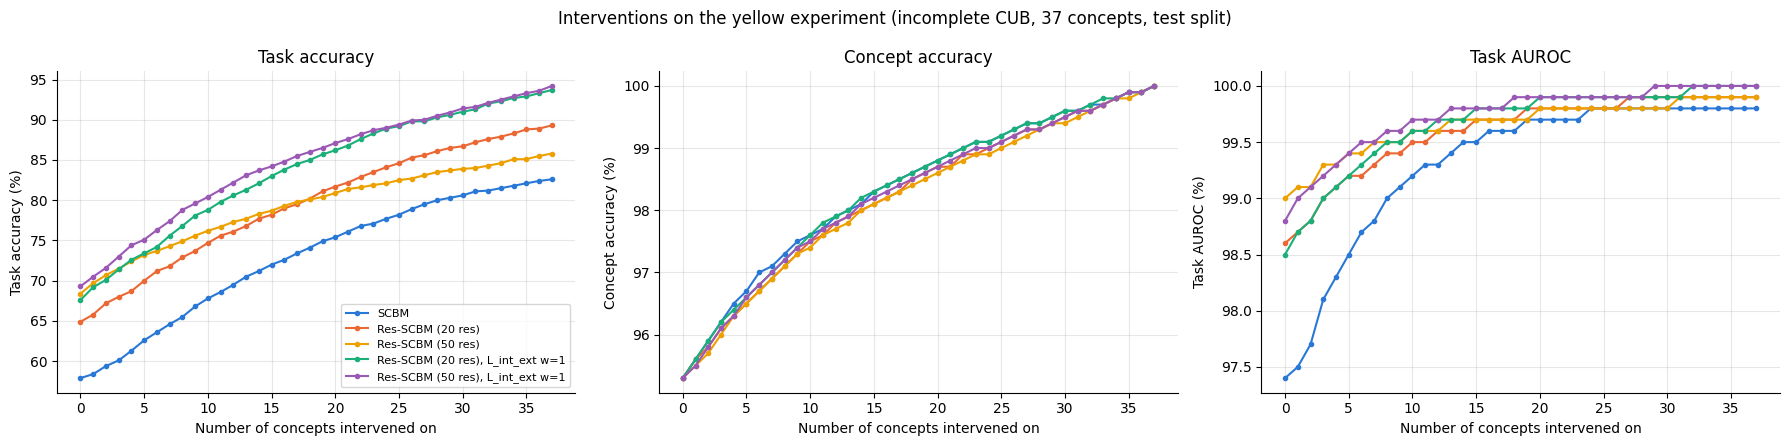

,model,y_acc @ 0,y_acc @ 18,y_acc @ 37
0,SCBM,57.9,74.1,82.6
1,Res-SCBM (20 res),64.9,80.2,89.3
2,Res-SCBM (50 res),68.4,80.1,85.8
3,"Res-SCBM (20 res), L_int_ext w=1",67.6,85.0,93.7
4,"Res-SCBM (50 res), L_int_ext w=1",69.3,86.0,94.2


In [20]:
# ---- Intervention curves for the yellow experiment ----
# Strategy is emp_perc / random policy on the test split for all five runs (see the log header).
PANELS = [("y_accuracy", "Task accuracy (%)"),
          ("c_accuracy", "Concept accuracy (%)"),
          ("y_AUROC", "Task AUROC (%)")]

fig, axes = plt.subplots(1, len(PANELS), figsize=(6 * len(PANELS), 4.5), sharex=True)
for ax, (metric, ylabel) in zip(axes, PANELS):
    for label, model_type, run_dir in YELLOW_RUNS:
        xs, curves = extract_info_from_intervention_log(run_dir, model_type=model_type, dataset="CUB")
        ys = curves[metric]
        keep = [(x, y) for x, y in zip(xs, ys) if y is not None]
        ax.plot([x for x, _ in keep], [y for _, y in keep], marker="o", markersize=3,
                color=YELLOW_COLORS[label], label=label)
    ax.set_xlabel("Number of concepts intervened on")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split(" (")[0])
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(fontsize=8)
fig.suptitle("Interventions on the yellow experiment (incomplete CUB, 37 concepts, test split)")
plt.tight_layout()
plt.savefig(os.path.join("plots", "yellow_experiment_intervention_curves.png"), dpi=200)
plt.show()

# Task accuracy at 0 / half / all concepts intervened, for the table.
rows = []
for label, model_type, run_dir in YELLOW_RUNS:
    xs, curves = extract_info_from_intervention_log(run_dir, model_type=model_type, dataset="CUB")
    by_x = dict(zip(xs, curves["y_accuracy"]))
    rows.append({"model": label, **{f"y_acc @ {n}": by_x.get(n) for n in (0, max(xs) // 2, max(xs))}})
df_yellow_int = pd.DataFrame(rows)
df_yellow_int.to_csv(os.path.join(root_save_dir, "yellow_experiment_intervention_curves.csv"), index=False)
df_yellow_int

## Model comparison on a set of classes

Linear head vs Res-SCBM (20 res, L_int_ext w=1) side by side, for any class
list -- e.g. one collision group, where the two models should behave differently:
the head reads only the 37 surviving concepts and cannot separate a group at all,
while the residual channel can.

In [21]:
# Same ordering as per_class_overview / cell above, so group indices match the printouts.
ordered_groups = sorted(groups_37, key=lambda g: (-len(g), g[0]))


def _frame_or_csv(df, var_name, csv_name):
    """The named frame if the cell that builds it has been run, else its saved CSV."""
    if df is None:
        df = globals().get(var_name)
    if df is None:
        df = pd.read_csv(os.path.join(root_save_dir, csv_name))
    return df


def compare_models_on_classes(class_labels, title="", df_lin=None, df_res=None):
    """Per-class accuracy for both models, restricted to class_labels.

    Defaults to the two frames built above: df_acc (linear head, cell '## Linear
    classifier') and df_acc_res20_lint (Res-SCBM 20 res, L_int_ext w=1).
    """
    df_lin = _frame_or_csv(df_lin, "df_acc",
                           "yellow_experiment_linear_head_per_class_acc.csv")
    df_res = _frame_or_csv(df_res, "df_acc_res20_lint",
                           "yellow_experiment_res_scbm_20_L_int_ext_per_class_acc.csv")

    m = (df_lin[["class_label", "class_name", "n_samples", "n_correct", "accuracy"]]
         .merge(df_res[["class_label", "n_correct", "accuracy"]],
                on="class_label", suffixes=("_lin", "_res")))
    m = m[m["class_label"].isin(list(class_labels))].sort_values("class_label")
    m["delta"] = m["accuracy_res"] - m["accuracy_lin"]

    if title:
        print(title)
    print(m.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

    n = m["n_samples"].sum()
    k_lin, k_res = m["n_correct_lin"].sum(), m["n_correct_res"].sum()
    print(f"\ntotal: n={n} | linear head {k_lin/n:.4f} ({k_lin}/{n})"
          f" | res-scbm L_int_ext {k_res/n:.4f} ({k_res}/{n})")
    return m


g = 0
df_group0 = compare_models_on_classes(
    ordered_groups[g],
    f"Group {g} - {len(ordered_groups[g])} classes")

display(df_group0)


Group 0 - 5 classes
 class_label                    class_name  n_samples  n_correct_lin  accuracy_lin  n_correct_res  accuracy_res  delta
          41      042.Vermilion_Flycatcher         30              0         0.000             22         0.733  0.733
          42 043.Yellow_bellied_Flycatcher         29              0         0.000              9         0.310  0.310
         162          163.Cape_May_Warbler         30              0         0.000             25         0.833  0.833
         172    173.Orange_crowned_Warbler         30             30         1.000             10         0.333 -0.667
         173              174.Palm_Warbler         30              0         0.000              3         0.100  0.100

total: n=149 | linear head 0.2013 (30/149) | res-scbm L_int_ext 0.4631 (69/149)


,class_label,class_name,n_samples,n_correct_lin,accuracy_lin,n_correct_res,accuracy_res,delta
41,41,042.Vermilion_Flycatcher,30,0,0.0,22,0.733333,0.733333
42,42,043.Yellow_bellied_Flycatcher,29,0,0.0,9,0.310345,0.310345
162,162,163.Cape_May_Warbler,30,0,0.0,25,0.833333,0.833333
172,172,173.Orange_crowned_Warbler,30,30,1.0,10,0.333333,-0.666667
173,173,174.Palm_Warbler,30,0,0.0,3,0.100000,0.100000


In [22]:
g = 8
df_group8 = compare_models_on_classes(
    ordered_groups[g],
    f"Group {g} - {len(ordered_groups[g])} classes")

display(df_group8)

Group 8 - 2 classes
 class_label               class_name  n_samples  n_correct_lin  accuracy_lin  n_correct_res  accuracy_res  delta
          19 020.Yellow_breasted_Chat         29             29         1.000             22         0.759 -0.241
         127      128.Seaside_Sparrow         30              0         0.000             19         0.633  0.633

total: n=59 | linear head 0.4915 (29/59) | res-scbm L_int_ext 0.6949 (41/59)


,class_label,class_name,n_samples,n_correct_lin,accuracy_lin,n_correct_res,accuracy_res,delta
19,19,020.Yellow_breasted_Chat,29,29,1.0,22,0.758621,-0.241379
127,127,128.Seaside_Sparrow,30,0,0.0,19,0.633333,0.633333


In [23]:
g = 15
df_group15 = compare_models_on_classes(
    ordered_groups[g],
    f"Group {g} - {len(ordered_groups[g])} classes")

display(df_group15)

Group 15 - 2 classes
 class_label             class_name  n_samples  n_correct_lin  accuracy_lin  n_correct_res  accuracy_res  delta
          76  077.Tropical_Kingbird         30             30         1.000             25         0.833 -0.167
         152 153.Philadelphia_Vireo         29              0         0.000             15         0.517  0.517

total: n=59 | linear head 0.5085 (30/59) | res-scbm L_int_ext 0.6780 (40/59)


,class_label,class_name,n_samples,n_correct_lin,accuracy_lin,n_correct_res,accuracy_res,delta
76,76,077.Tropical_Kingbird,30,30,1.0,25,0.833333,-0.166667
152,152,153.Philadelphia_Vireo,29,0,0.0,15,0.517241,0.517241


## Group information

In [24]:
import itertools
import numpy as np
import pandas as pd


# ============================================================
# 1. Build one FULL 112-dimensional ground-truth vector/class
# ============================================================

A_full = np.stack(df_cub["attribute_label"].to_numpy()).astype(np.int8)
y_full = df_cub["class_label"].to_numpy()

full_class_vec = {}

for c in np.unique(y_full):
    rows = np.unique(A_full[y_full == c], axis=0)

    # Your class-wise CUB labels should give exactly one vector per class
    assert len(rows) == 1, (
        f"Class {c} has {len(rows)} different full concept vectors."
    )

    full_class_vec[int(c)] = rows[0]

print("Number of classes:", len(full_class_vec))
print("Full concept dimensionality:", A_full.shape[1])


# ============================================================
# 2. Determine which of the 112 concepts were removed
# ============================================================

# attr_idx_mapping_dict:
# old 112-dim index -> new 37-dim index
kept_old_idxs = sorted(attr_idx_mapping_dict.keys())

removed_old_idxs = sorted(
    set(range(A_full.shape[1])) - set(kept_old_idxs)
)

print(f"Kept concepts:    {len(kept_old_idxs)}")
print(f"Removed concepts: {len(removed_old_idxs)}")


# ============================================================
# 3. Helper: find smallest removed-concept subset that uniquely
#    separates all classes inside one collision group
# ============================================================

def find_minimal_separator(class_group, removed_idxs):
    """
    Find the smallest subset of removed concepts for which all classes
    in class_group have unique projected concept vectors.

    Returns
    -------
    varying_idxs:
        All removed concepts that differ somewhere inside the group.

    minimal_sets:
        All smallest concept-index subsets that uniquely identify every
        class in the collision group.
    """

    # [num_classes, 112]
    X = np.stack([full_class_vec[c] for c in class_group])

    # Only inspect removed concepts
    X_removed = X[:, removed_idxs]

    # Concepts that actually vary across the classes
    varying_mask = np.ptp(X_removed, axis=0) > 0

    varying_idxs = [
        removed_idxs[j]
        for j in np.flatnonzero(varying_mask)
    ]

    # If even the complete removed space cannot distinguish them
    if len(varying_idxs) == 0:
        return [], []

    # Search from smallest possible subset upward
    for subset_size in range(1, len(varying_idxs) + 1):

        valid_sets = []

        for subset in itertools.combinations(varying_idxs, subset_size):

            projected = np.stack([
                full_class_vec[c][list(subset)]
                for c in class_group
            ])

            # Are all class vectors unique using this subset?
            if len(np.unique(projected, axis=0)) == len(class_group):
                valid_sets.append(subset)

        # First size with a valid solution is minimal
        if valid_sets:
            return varying_idxs, valid_sets

    return varying_idxs, []


# ============================================================
# 4. Analyse every 37-concept collision group
# ============================================================

ordered_groups = sorted(
    groups_37,
    key=lambda g: (-len(g), g[0])
)

results = []

for group_id, group in enumerate(ordered_groups):

    varying_idxs, minimal_sets = find_minimal_separator(
        group,
        removed_old_idxs
    )

    class_names_group = [
        class_id_to_name[c]
        for c in group
    ]

    varying_names = [
        attr_idx_to_names[i]
        for i in varying_idxs
    ]

    # Take first minimum-size solution for compact summary
    if minimal_sets:
        chosen_set = minimal_sets[0]
        chosen_names = [
            attr_idx_to_names[i]
            for i in chosen_set
        ]
    else:
        chosen_set = []
        chosen_names = []

    results.append({
        "collision_group": group_id,
        "n_classes": len(group),
        "classes": class_names_group,
        "n_differing_removed_concepts": len(varying_idxs),
        "minimal_separator_size": len(chosen_set),
        "minimal_separator": chosen_names,
        "all_differing_removed_concepts": varying_names,
        "n_minimal_solutions": len(minimal_sets),
    })


df_collision_separators = pd.DataFrame(results)

display(
    df_collision_separators[
        [
            "collision_group",
            "n_classes",
            "classes",
            "minimal_separator_size",
            "minimal_separator",
            "n_differing_removed_concepts",
        ]
    ]
)

Number of classes: 200
Full concept dimensionality: 112
Kept concepts:    37
Removed concepts: 75


,collision_group,n_classes,classes,minimal_separator_size,minimal_separator,n_differing_removed_concepts
0,0,5,"[042.Vermilion_Flycatcher, 043.Yellow_bellied_...",3,"[has_upperparts_color::brown, has_underparts_c...",22
1,1,4,"[004.Groove_billed_Ani, 025.Pelagic_Cormorant,...",3,"[has_bill_length::about_the_same_as_head, has_...",7
2,2,4,"[060.Glaucous_winged_Gull, 062.Herring_Gull, 0...",2,"[has_under_tail_color::black, has_back_pattern...",12
3,3,3,"[009.Brewer_Blackbird, 029.American_Crow, 049....",2,"[has_back_color::black, has_head_pattern::plain]",9
4,4,3,"[143.Caspian_Tern, 145.Elegant_Tern, 146.Forst...",2,"[has_upperparts_color::grey, has_nape_color::b...",14
5,5,2,"[010.Red_winged_Blackbird, 107.Common_Raven]",1,[has_bill_length::about_the_same_as_head],6
6,6,2,"[014.Indigo_Bunting, 016.Painted_Bunting]",1,[has_tail_shape::notched_tail],5
7,7,2,"[018.Spotted_Catbird, 140.Summer_Tanager]",1,[has_breast_pattern::solid],6
8,8,2,"[020.Yellow_breasted_Chat, 128.Seaside_Sparrow]",1,[has_underparts_color::yellow],15
9,9,2,"[023.Brandt_Cormorant, 024.Red_faced_Cormorant]",1,[has_head_pattern::plain],2


In [25]:
def show_collision_separator(group_id):
    """
    Display the classes in a collision group and their values
    for one minimal set of removed concepts.
    """

    group = ordered_groups[group_id]

    varying_idxs, minimal_sets = find_minimal_separator(
        group,
        removed_old_idxs
    )

    if not minimal_sets:
        print("No separating subset found.")
        return None

    # First minimal solution
    separator = minimal_sets[0]

    rows = []

    for c in group:
        row = {
            "class_label": c,
            "class_name": class_id_to_name[c],
        }

        for idx in separator:
            row[attr_idx_to_names[idx]] = int(
                full_class_vec[c][idx]
            )

        rows.append(row)

    out = pd.DataFrame(rows)

    print(f"Collision group {group_id}")
    print(f"Classes: {len(group)}")
    print(f"Minimum concepts required: {len(separator)}")
    print(
        "Separator:",
        [attr_idx_to_names[i] for i in separator]
    )

    return out

In [26]:
display(show_collision_separator(8))

Collision group 8
Classes: 2
Minimum concepts required: 1
Separator: ['has_underparts_color::yellow']


,class_label,class_name,has_underparts_color::yellow
0,19,020.Yellow_breasted_Chat,1
1,127,128.Seaside_Sparrow,0


### All minimal seperating groups

In [27]:
def show_all_minimal_separators(group_id):
    group = ordered_groups[group_id]

    varying_idxs, minimal_sets = find_minimal_separator(
        group,
        removed_old_idxs
    )

    print("Classes:")
    for c in group:
        print(f"  {c:3d}  {class_id_to_name[c]}")

    print(f"\nAll removed concepts that vary ({len(varying_idxs)}):")
    for i in varying_idxs:
        print(f"  {i:3d}  {attr_idx_to_names[i]}")

    if not minimal_sets:
        print("\nNo separating set found.")
        return

    print(
        f"\nMinimum separator size = "
        f"{len(minimal_sets[0])}"
    )

    print(
        f"Number of minimum-size solutions = "
        f"{len(minimal_sets)}"
    )

    for j, subset in enumerate(minimal_sets):
        print(
            f"{j + 1:2d}: "
            f"{[attr_idx_to_names[i] for i in subset]}"
        )

In [28]:
show_all_minimal_separators(8)

Classes:
   19  020.Yellow_breasted_Chat
  127  128.Seaside_Sparrow

All removed concepts that vary (15):
   18  has_underparts_color::yellow
   22  has_breast_pattern::solid
   25  has_back_color::brown
   41  has_breast_color::yellow
   46  has_throat_color::yellow
   65  has_nape_color::grey
   72  has_belly_color::yellow
   83  has_back_pattern::solid
   86  has_tail_pattern::solid
   89  has_belly_pattern::solid
   92  has_primary_color::yellow
   96  has_leg_color::grey
   99  has_bill_color::grey
  100  has_bill_color::black
  108  has_wing_pattern::solid

Minimum separator size = 1
Number of minimum-size solutions = 15
 1: ['has_underparts_color::yellow']
 2: ['has_breast_pattern::solid']
 3: ['has_back_color::brown']
 4: ['has_breast_color::yellow']
 5: ['has_throat_color::yellow']
 6: ['has_nape_color::grey']
 7: ['has_belly_color::yellow']
 8: ['has_back_pattern::solid']
 9: ['has_tail_pattern::solid']
10: ['has_belly_pattern::solid']
11: ['has_primary_color::yellow']
12: ['

## Inspect covariance matrices

020.Yellow_breasted_Chat: 29 test samples, cov (29, 57, 57)


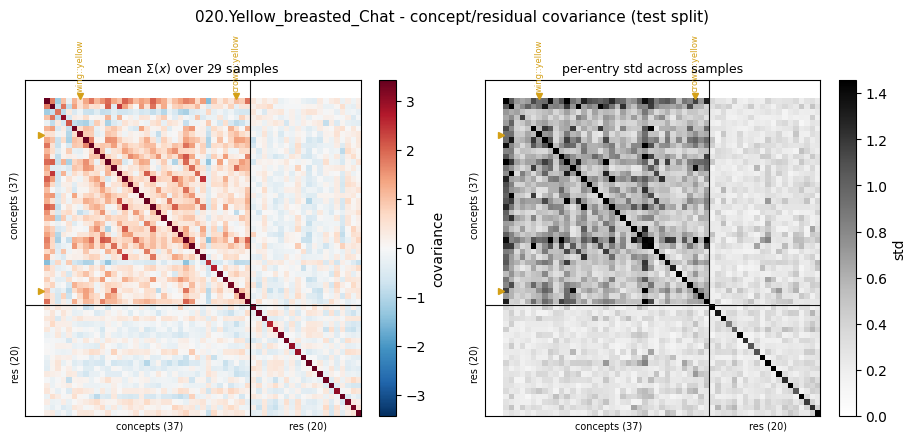

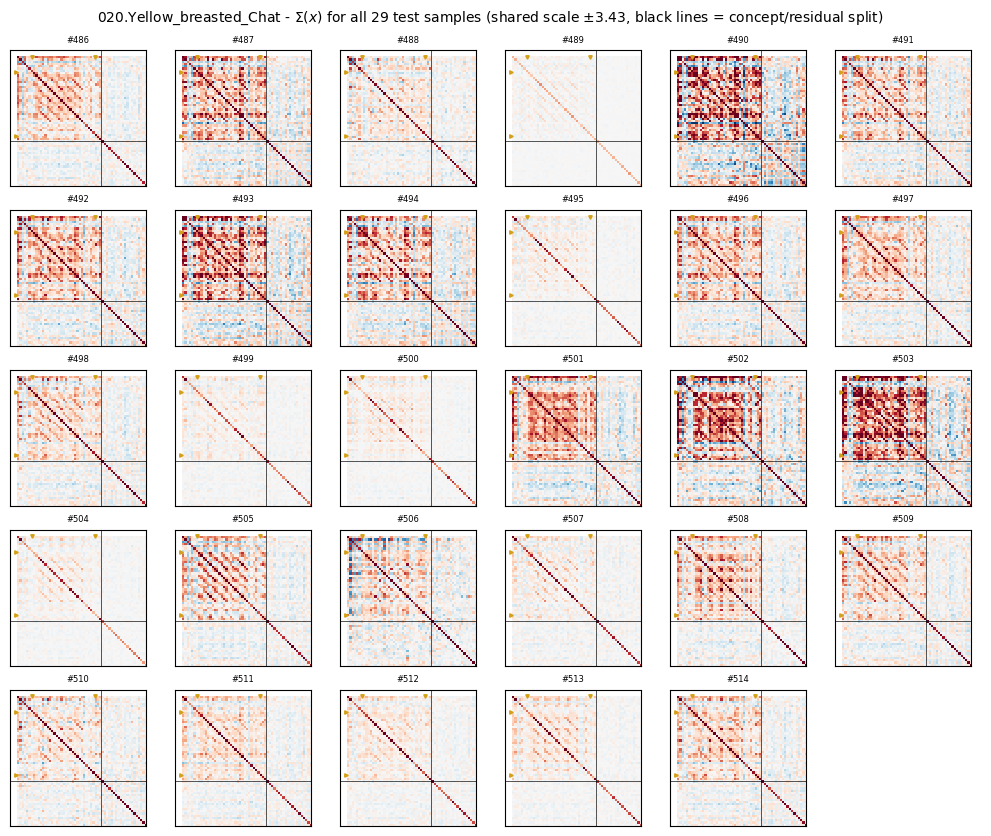

||Sigma - mean||_F / ||mean||_F : min 0.219 med 0.575 max 1.400
cross-block |Sigma_cr| mean 0.3151 max 3.1147


In [29]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

RUN = os.path.join(
    "experiments", "scbm_residual", "CUB",
    "yellow_experiment_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-09-02_16-12-55_d1750")
N_C, N_R = 37, 20                       # 37 surviving concepts | 20 residuals
OUT = "plots"

CLASS_LABEL, CLASS_NAME = 19, "020.Yellow_breasted_Chat"
# group 0: 41 Vermilion_Flycatcher, 42 Yellow_bellied_Flycatcher,
#          162 Cape_May_Warbler, 172 Orange_crowned_Warbler, 173 Palm_Warbler

y = torch.load(f"{RUN}/test/y_true.pt", map_location="cpu").numpy().ravel()
rows = np.flatnonzero(y == CLASS_LABEL)
cov = torch.load(f"{RUN}/test/covariance_matrices.pt", map_location="cpu").float().numpy()[rows]
print(f"{CLASS_NAME}: {len(rows)} test samples, cov {cov.shape}")

# Colour limit from the off-diagonal only -- the diagonal holds the variances and
# is ~20x larger, so including it would wash out all cross-term structure.
off = ~np.eye(N_C + N_R, dtype=bool)
v = np.percentile(np.abs(cov[:, off]), 99.5)


# The two yellow attributes that survive the yellow_experiment_local_1 removal
# (every other yellow attribute is a hidden concept). Indices are in the 37-dim
# surviving space; see the info.txt mapping cell above.
YELLOW_AXES = {6: "wing::yellow", 34: "crown::yellow"}
YELLOW = "#d4a017"


def blocks(ax, lw=0.8, names=False):
    """Mark the concept/residual split and the two surviving yellow concepts."""
    ax.axhline(N_C - .5, color="#111", lw=lw)
    ax.axvline(N_C - .5, color="#111", lw=lw)

    # Markers sit just outside the image so they never cover the cells of interest.
    pad = 1.0 if names else 0.8
    for i, nm in YELLOW_AXES.items():
        ax.plot(-pad, i, marker=">", ms=4 if names else 2.5, color=YELLOW, clip_on=False)
        ax.plot(i, -pad, marker="v", ms=4 if names else 2.5, color=YELLOW, clip_on=False)
        if names:
            ax.text(i, -1.8, nm, rotation=90, ha="center", va="bottom",
                    fontsize=6, color=YELLOW)

    ax.set_xticks([N_C / 2, N_C + N_R / 2])
    ax.set_yticks([N_C / 2, N_C + N_R / 2])
    ax.set_xticklabels(["concepts (37)", "res (20)"], fontsize=7)
    ax.set_yticklabels(["concepts (37)", "res (20)"], fontsize=7, rotation=90, va="center")
    ax.tick_params(length=0)


# ---- mean over the class's samples, and how much it varies ---------------
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.3), constrained_layout=True)
m = cov.mean(0)
im = axes[0].imshow(m, cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
axes[0].set_title(f"mean $\\Sigma(x)$ over {len(rows)} samples", fontsize=9)
fig.colorbar(im, ax=axes[0], fraction=.046, label="covariance")

s = cov.std(0)
im2 = axes[1].imshow(s, cmap="Greys", vmin=0, vmax=np.percentile(s[off], 99.5),
                     interpolation="nearest")
axes[1].set_title("per-entry std across samples", fontsize=9)
fig.colorbar(im2, ax=axes[1], fraction=.046, label="std")

for ax in axes:
    blocks(ax, names=True)
fig.suptitle(f"{CLASS_NAME} - concept/residual covariance (test split)", fontsize=11)
fig.savefig(f"{OUT}/cov_{CLASS_NAME}_mean.png", dpi=170)
plt.show()

# ---- every sample, shared colour scale ----------------------------------
n, ncol = len(rows), 6
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(1.65 * ncol, 1.65 * nrow), constrained_layout=True)
for i, ax in enumerate(axes.ravel()):
    if i >= n:
        ax.axis("off")
        continue
    ax.imshow(cov[i], cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
    blocks(ax, lw=.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"#{rows[i]}", fontsize=6)
fig.suptitle(f"{CLASS_NAME} - $\\Sigma(x)$ for all {n} test samples "
             f"(shared scale $\\pm${v:.2f}, black lines = concept/residual split)", fontsize=10)
fig.savefig(f"{OUT}/cov_{CLASS_NAME}_all_samples.png", dpi=170)
plt.show()

# ---- how input-dependent is Sigma within this class? --------------------
fro = np.linalg.norm(cov - m, axis=(1, 2)) / np.linalg.norm(m)
print(f"||Sigma - mean||_F / ||mean||_F : min {fro.min():.3f} "
      f"med {np.median(fro):.3f} max {fro.max():.3f}")
cr = cov[:, :N_C, N_C:]
print(f"cross-block |Sigma_cr| mean {np.abs(cr).mean():.4f} max {np.abs(cr).max():.4f}")


### Correlation matrices

Same three views on `corr(Sigma(x))` instead of `Sigma(x)`. The residual block
carries much larger variances than the concept block, so raw covariance
under-reads concept-residual dependence relative to within-block dependence;
normalising puts every entry on the same [-1, 1] scale. `block_diagonal_cov` is
`False` for this run, so the cross block is free -- nothing but the L1 precision
penalty pushes it toward zero.

020.Yellow_breasted_Chat: 22/29 correctly predicted (0.759); wrong -> classes [95, 127, 156, 161, 175, 192, 199]


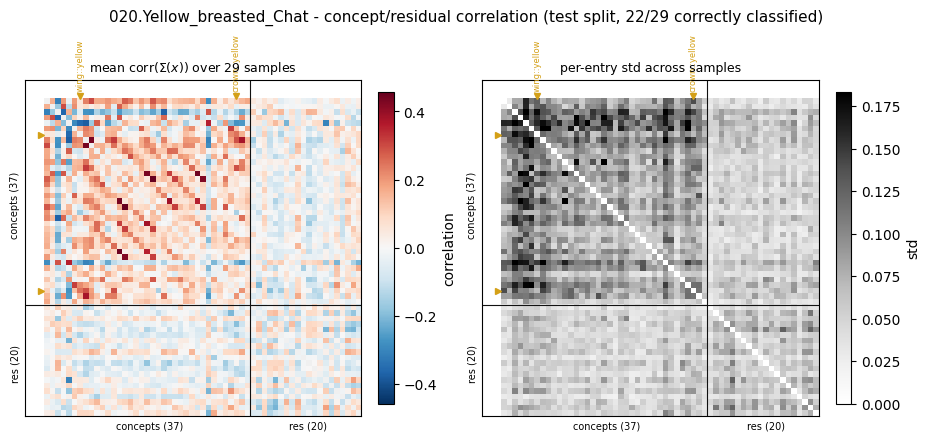

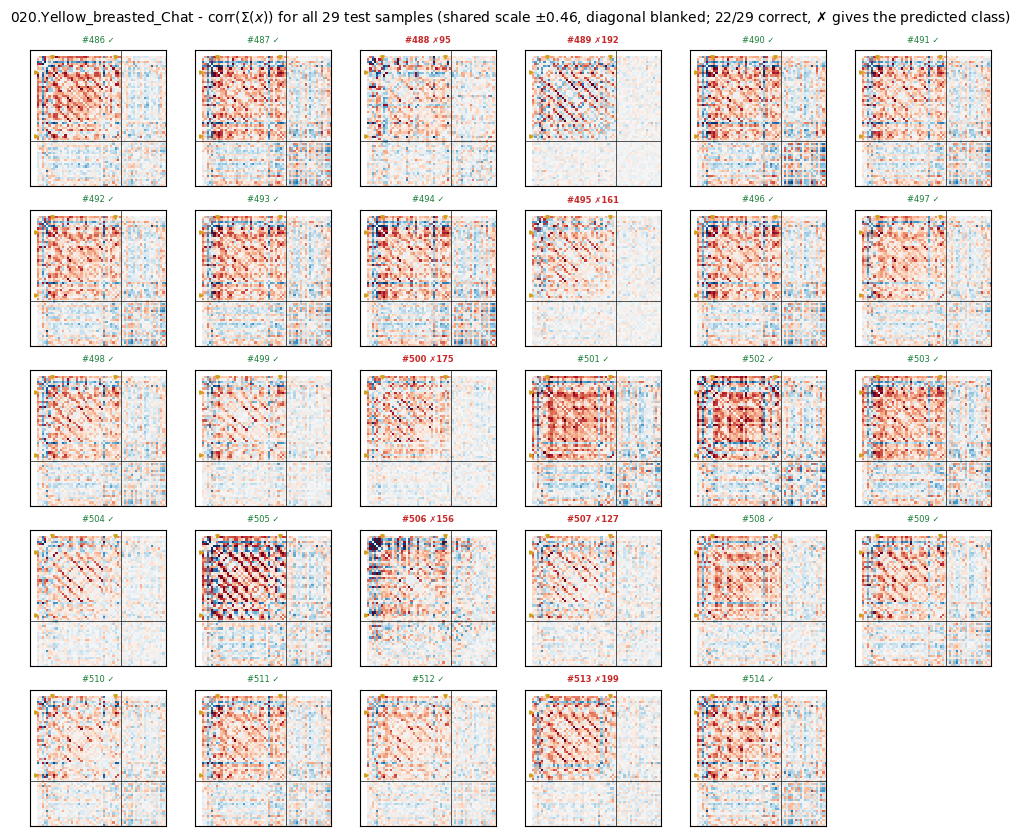

block                 mean|r|   p99|r|   max|r|  frac>0.1
concept-concept        0.1367   0.4706   0.7500    0.5609
residual-residual      0.0810   0.2788   0.4221    0.3212
concept-residual       0.0686   0.2446   0.4282    0.2459


In [41]:
# ---- the same three views, on the correlation matrices -------------------
# corr = D Sigma D with D = diag(1/sqrt(diag Sigma)). This strips the per-dimension
# variance scale, which matters here: the residual block carries far more variance
# than the concept block, so in Sigma a strong concept-residual dependence and a
# weak one look similar. In corr every entry is on the same [-1, 1] scale.
d = np.sqrt(np.einsum("...ii->...i", cov))              # [n, C+R] per-dim std
corr = cov / (d[:, :, None] * d[:, None, :])
corr = np.clip(corr, -1.0, 1.0)                         # guard float32 drift

diag = np.eye(N_C + N_R, dtype=bool)
vc = np.percentile(np.abs(corr[:, off]), 99.5)
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#f0f0f0")                                 # masked diagonal

# ---- was the task prediction right for each of this class's samples? ----
# y_pred.pt is log(mean_m softmax(...)) -- log-probabilities, so argmax is the
# predicted class directly.
y_pred_log = torch.load(f"{RUN}/test/y_pred.pt", map_location="cpu").numpy()
pred_cls = y_pred_log.argmax(1)[rows]
ok = pred_cls == y[rows]
OK_C, BAD_C = "#1a7f37", "#c62828"
print(f"{CLASS_NAME}: {ok.sum()}/{len(rows)} correctly predicted "
      f"({ok.mean():.3f}); wrong -> classes {sorted(set(pred_cls[~ok].tolist()))}")


def no_diag(a):
    """Blank the diagonal -- it is identically 1 and would saturate the scale."""
    a = a.copy()
    a[..., diag] = np.nan
    return a


# ---- mean over the class's samples, and how much it varies ---------------
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.3), constrained_layout=True)
mc = corr.mean(0)
im = axes[0].imshow(no_diag(mc), cmap=cmap, vmin=-vc, vmax=vc, interpolation="nearest")
axes[0].set_title(f"mean corr($\\Sigma(x)$) over {len(rows)} samples", fontsize=9)
fig.colorbar(im, ax=axes[0], fraction=.046, label="correlation")

sc = corr.std(0)
im2 = axes[1].imshow(no_diag(sc), cmap="Greys", vmin=0,
                     vmax=np.percentile(sc[off], 99.5), interpolation="nearest")
axes[1].set_title("per-entry std across samples", fontsize=9)
fig.colorbar(im2, ax=axes[1], fraction=.046, label="std")

for ax in axes:
    blocks(ax, names=True)
fig.suptitle(f"{CLASS_NAME} - concept/residual correlation (test split, "
             f"{ok.sum()}/{len(rows)} correctly classified)", fontsize=11)
fig.savefig(f"{OUT}/corr_{CLASS_NAME}_mean.png", dpi=170)
plt.show()

# ---- every sample, shared colour scale ----------------------------------
fig, axes = plt.subplots(nrow, ncol, figsize=(1.65 * ncol, 1.65 * nrow),
                         constrained_layout=True)
for i, ax in enumerate(axes.ravel()):
    if i >= n:
        ax.axis("off")
        continue
    ax.imshow(no_diag(corr[i]), cmap=cmap, vmin=-vc, vmax=vc, interpolation="nearest")
    blocks(ax, lw=.5)
    ax.set_xticks([]); ax.set_yticks([])
    # Green check = task head got the class right; red cross names what it said instead.
    ax.set_title(f"#{rows[i]} " + ("\u2713" if ok[i] else f"\u2717{pred_cls[i]}"),
                 fontsize=6, color=OK_C if ok[i] else BAD_C,
                 fontweight="normal" if ok[i] else "bold")
fig.suptitle(f"{CLASS_NAME} - corr($\\Sigma(x)$) for all {n} test samples "
             f"(shared scale $\\pm${vc:.2f}, diagonal blanked; "
             f"{ok.sum()}/{n} correct, \u2717 gives the predicted class)", fontsize=10)
fig.savefig(f"{OUT}/corr_{CLASS_NAME}_all_samples.png", dpi=170)
plt.show()

# ---- block-wise summary -------------------------------------------------
# The concept-residual block is the one that matters for the leakage question:
# block_diagonal_cov=False, so nothing forces it to zero.
blk = {
    "concept-concept": corr[:, :N_C, :N_C][:, ~np.eye(N_C, dtype=bool)],
    "residual-residual": corr[:, N_C:, N_C:][:, ~np.eye(N_R, dtype=bool)],
    "concept-residual": corr[:, :N_C, N_C:].reshape(n, -1),
}
print(f"{'block':<20}{'mean|r|':>9}{'p99|r|':>9}{'max|r|':>9}{'frac>0.1':>10}")
for name, a in blk.items():
    a = np.abs(a)
    print(f"{name:<20}{a.mean():>9.4f}{np.percentile(a, 99):>9.4f}"
          f"{a.max():>9.4f}{(a > 0.1).mean():>10.4f}")


In [31]:
YELLOW_KEPT = {6: "has_wing_color::yellow", 34: "has_crown_color::yellow"}
other = [c for c in range(N_C) if c not in YELLOW_KEPT]

cr = np.abs(corr[:, :N_C, N_C:])          # [n, C, R]
null = cr[:, other, :].mean()             # mean |r| over non-yellow concept rows

print(f"{'concept':<28}{'mean|r|':>9}{'max|r|':>9}{'argmax dim':>12}{'vs null':>9}")
for ci, cname in YELLOW_KEPT.items():
    row = cr[:, ci, :]                    # [n, R]
    per_dim = row.mean(0)                 # [R]
    print(f"{cname:<28}{row.mean():>9.4f}{per_dim.max():>9.4f}"
          f"{int(per_dim.argmax()):>12}{row.mean()/null:>9.2f}x")
print(f"{'(null: other 35 concepts)':<28}{null:>9.4f}")

# signed per-dim profile -- the thing to compare across classes
prof = corr[:, list(YELLOW_KEPT), N_C:].mean(0)   # [2, R]

concept                       mean|r|   max|r|  argmax dim  vs null
has_wing_color::yellow         0.0733   0.1440           5     1.08x
has_crown_color::yellow        0.0847   0.1923           3     1.25x
(null: other 35 concepts)      0.0680


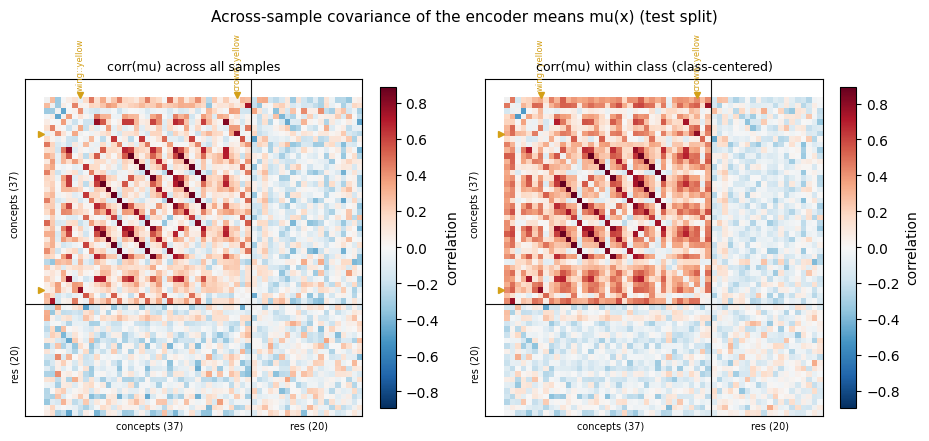

||E[Sigma] + Cov(mu) - Cov(eta_MC_mean)||_F / ||.||_F = 0.04879899981492847
res_0     0.456281
res_18    0.394680
res_16    0.367064
res_7     0.359830
res_6     0.358120
res_19    0.336845
res_14    0.334889
res_13    0.325499
res_8     0.323467
res_9     0.322857
dtype: float64
has_wing_color::black            0.456281
has_wing_shape::rounded-wings    0.394680
has_breast_color::white          0.367064
has_wing_color::white            0.363998
has_wing_color::grey             0.359830
has_wing_color::brown            0.358120
has_bill_shape::all-purpose      0.334889
has_underparts_color::white      0.333415
has_wing_shape::pointed-wings    0.325499
has_underparts_color::brown      0.322353
dtype: float64


In [43]:
# ---- covariance of the mu vectors (across samples) -----------------------------
# Complement to Sigma(x): total Cov(eta) = E_x[Sigma(x)] + Cov_x[mu(x)].
# Sigma(x) is within-image; this is across-image structure of the encoder means.

def mu_covariance(split="test", corr=False, center="global", run=RUN):
    """Empirical covariance of mu(x) = c_res_mu over the split. [C+R, C+R].

    center: 'global' -> subtract the dataset mean (raw across-sample covariance;
                        dominated by class structure, since mu tracks the class
                        attribute vector).
            'class'  -> subtract each sample's class mean, i.e. within-class
                        covariance: the mu-variation the label does NOT explain.
                        This is the one to read for "does res_r track concept c
                        beyond what the class already implies".
    """
    P = _preds(split) if run == RUN else load_preds(split, run)
    MU = P["c_res_mu"].astype(np.float64)                 # [n, C+R]
    y = P["y_true"].ravel().astype(int)

    if center == "class":
        X = MU.copy()
        for c in np.unique(y):
            m = y == c
            X[m] -= X[m].mean(0)
        # dof: n - n_classes (one mean estimated per class)
        S = X.T @ X / (len(X) - len(np.unique(y)))
    else:
        S = np.cov(MU, rowvar=False)                      # dof n-1

    if corr:
        d = np.sqrt(np.diag(S))
        S = np.clip(S / np.outer(d, d), -1.0, 1.0)
    return S


def mu_cov_df(split="test", corr=False, center="global", block="full"):
    S = mu_covariance(split, corr=corr, center=center)
    sl = {"full": (slice(None), slice(None)),
          "cc": (slice(0, N_C), slice(0, N_C)),
          "rr": (slice(N_C, None), slice(N_C, None)),
          "cr": (slice(0, N_C), slice(N_C, None))}[block]
    rows = axis_names[sl[0]] if block != "cr" else concept_names
    cols = axis_names[sl[1]] if block != "cr" else residual_names
    return pd.DataFrame(S[sl], index=rows, columns=cols)


# ---- plot: global vs class-centered correlation of mu --------------------------
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.3), constrained_layout=True)
for ax, ctr, ttl in zip(axes, ["global", "class"],
                        ["corr(mu) across all samples",
                         "corr(mu) within class (class-centered)"]):
    C = mu_covariance("test", corr=True, center=ctr)
    lim = np.percentile(np.abs(C[off]), 99.5)
    im = ax.imshow(no_diag(C), cmap=cmap, vmin=-lim, vmax=lim, interpolation="nearest")
    ax.set_title(ttl, fontsize=9)
    fig.colorbar(im, ax=ax, fraction=.046, label="correlation")
    blocks(ax, names=True)
fig.suptitle("Across-sample covariance of the encoder means mu(x) (test split)", fontsize=11)
fig.savefig(f"{OUT}/mu_corr_test.png", dpi=170)
plt.show()

# ---- sanity: does the decomposition hold? -------------------------------------
P = _preds("test")
tot_emp = np.cov(P["concepts_residuals_logits_mean"].astype(np.float64), rowvar=False)
recon = P["cov"].astype(np.float64).mean(0) + mu_covariance("test")
print("||E[Sigma] + Cov(mu) - Cov(eta_MC_mean)||_F / ||.||_F =",
      np.linalg.norm(recon - tot_emp) / np.linalg.norm(tot_emp))
# not exactly 0: tot_emp uses the MC mean of eta, not eta itself, so it under-counts
# the within-sample term by ~1/M. Order-of-magnitude agreement is the check.

# ---- the block you actually care about: which residual tracks which concept ----
cr = mu_cov_df("test", corr=True, center="class", block="cr")
print(cr.abs().max(axis=0).sort_values(ascending=False).head(10))   # most concept-coupled residuals
print(cr.abs().max(axis=1).sort_values(ascending=False).head(10))   # most residual-coupled concepts


020.Yellow_breasted_Chat: 22/29 correct, dims = 57, rank(Cov) <= 21


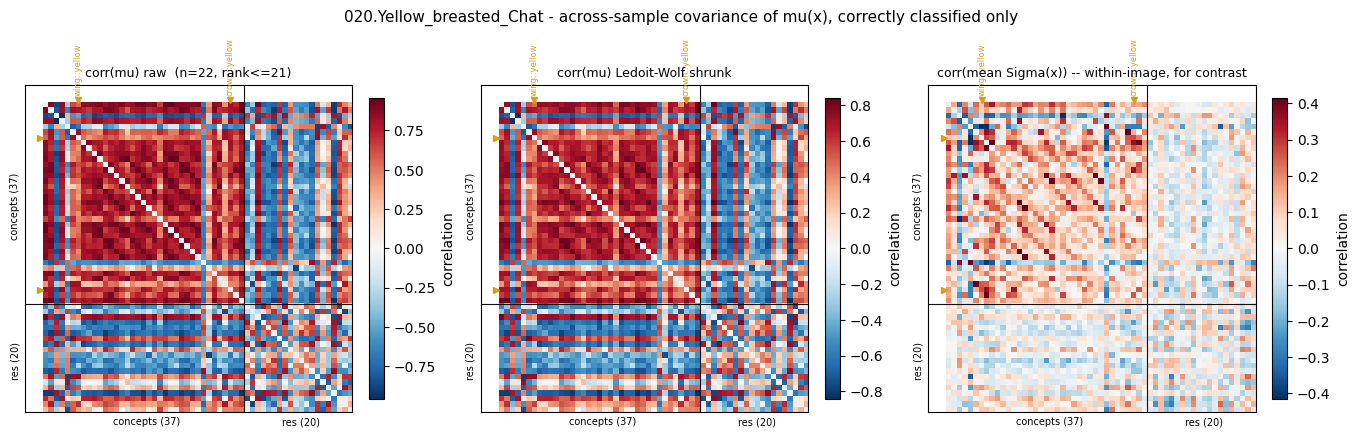


strongest concept-residual couplings (shrunk):
                    concept residual      corr
    has_breast_color::white    res_2  0.849972
     has_crown_color::white   res_16 -0.839564
      has_belly_color::grey   res_16 -0.823774
    has_breast_color::white   res_16 -0.821236
     has_belly_color::white    res_2  0.819573
    has_throat_color::white   res_16 -0.819497
     has_bill_shape::dagger    res_2  0.803601
has_underparts_color::white    res_2  0.799223
    has_throat_color::white    res_2  0.798915
has_underparts_color::white   res_16 -0.794739
      has_wing_color::brown   res_13 -0.793440
     has_belly_color::white   res_16 -0.787810

top-3 eigenvalue share of Cov(mu): 0.831   (n=22, so at most 21 nonzero)


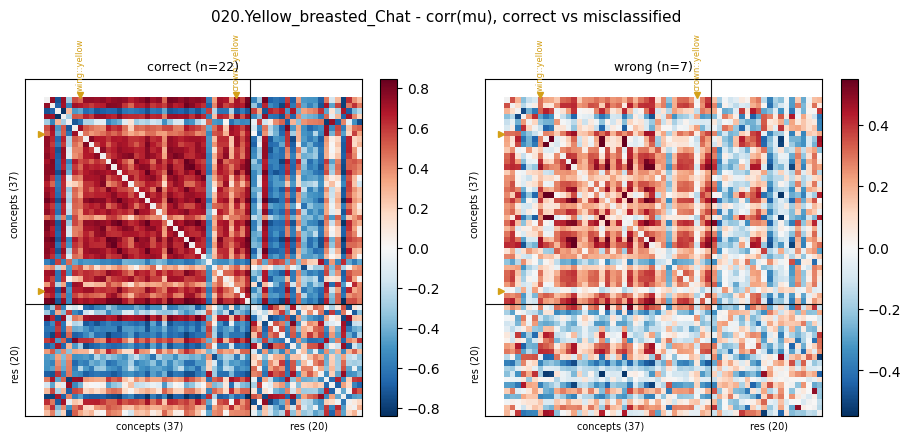

In [44]:
# ---- Cov(mu) over the correctly-predicted samples of one class ------------------
# Reuses `rows` / `ok` / `pred_cls` from the class-grid cell above (CLASS_LABEL = 19).
# Within a single class there is no class mean to remove beyond the subset mean, so
# this IS the within-class mu-covariance -- the encoder-mean spread that the label
# does not explain. Small n: rank(Cov) <= n-1 << C+R, so prefer the shrunk version.

from sklearn.covariance import LedoitWolf

P = _preds("test")
sel = rows[ok]                                   # correct only
print(f"{CLASS_NAME}: {len(sel)}/{len(rows)} correct, "
      f"dims = {N_C + N_R}, rank(Cov) <= {len(sel) - 1}")

MU = P["c_res_mu"][sel].astype(np.float64)       # [n_correct, C+R]

S_emp = np.cov(MU, rowvar=False)                 # raw, rank-deficient
S_lw  = LedoitWolf().fit(MU).covariance_         # shrunk, full-rank, invertible

def to_corr(S):
    d = np.sqrt(np.diag(S))
    return np.clip(S / np.outer(d, d), -1.0, 1.0)

# ---- three panels: raw mu-corr | shrunk mu-corr | mean Sigma(x) corr -----------
mean_sigma_corr = to_corr(P["cov"][sel].astype(np.float64).mean(0))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3), constrained_layout=True)
for ax, M, ttl in zip(
        axes,
        [to_corr(S_emp), to_corr(S_lw), mean_sigma_corr],
        [f"corr(mu) raw  (n={len(sel)}, rank<={len(sel)-1})",
         "corr(mu) Ledoit-Wolf shrunk",
         "corr(mean Sigma(x)) -- within-image, for contrast"]):
    lim = np.percentile(np.abs(M[off]), 99.5)
    im = ax.imshow(no_diag(M), cmap=cmap, vmin=-lim, vmax=lim, interpolation="nearest")
    ax.set_title(ttl, fontsize=9)
    fig.colorbar(im, ax=ax, fraction=.046, label="correlation")
    blocks(ax, names=True)
fig.suptitle(f"{CLASS_NAME} - across-sample covariance of mu(x), correctly classified only",
             fontsize=11)
fig.savefig(f"{OUT}/mu_corr_{CLASS_NAME}_correct.png", dpi=170)
plt.show()

# ---- the concept x residual block, named ---------------------------------------
cr = pd.DataFrame(to_corr(S_lw)[:N_C, N_C:], index=concept_names, columns=residual_names)
print("\nstrongest concept-residual couplings (shrunk):")
pairs = (cr.stack().rename("corr").reset_index()
           .rename(columns={"level_0": "concept", "level_1": "residual"}))
print(pairs.reindex(pairs["corr"].abs().sort_values(ascending=False).index).head(12)
           .to_string(index=False))

# how much of the mu spread lives in how few directions
ev = np.linalg.eigvalsh(S_emp)[::-1]
print(f"\ntop-3 eigenvalue share of Cov(mu): {ev[:3].sum() / ev.sum():.3f}"
      f"   (n={len(sel)}, so at most {len(sel)-1} nonzero)")

# ---- same thing for the misclassified samples, if there are enough -------------
sel_bad = rows[~ok]
if len(sel_bad) >= 5:
    S_bad = LedoitWolf().fit(P["c_res_mu"][sel_bad].astype(np.float64)).covariance_
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.3), constrained_layout=True)
    for ax, M, ttl in zip(axes, [to_corr(S_lw), to_corr(S_bad)],
                          [f"correct (n={len(sel)})", f"wrong (n={len(sel_bad)})"]):
        lim = np.percentile(np.abs(M[off]), 99.5)
        im = ax.imshow(no_diag(M), cmap=cmap, vmin=-lim, vmax=lim, interpolation="nearest")
        ax.set_title(ttl, fontsize=9); fig.colorbar(im, ax=ax, fraction=.046)
        blocks(ax, names=True)
    fig.suptitle(f"{CLASS_NAME} - corr(mu), correct vs misclassified", fontsize=11)
    plt.show()
else:
    print(f"\nonly {len(sel_bad)} misclassified samples -- too few for a covariance")


## Images

In [32]:
pkl_path = os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", f"test.pkl")
with open(pkl_path, "rb") as f:
    imgs = pickle.load(f)
    print(imgs[0].keys())
    

dict_keys(['id', 'img_path', 'class_label', 'attribute_label', 'attribute_certainty'])


#494  class=19  img_path=datasets/CUB/CUB_200_2011/CUB_200_2011/images/020.Yellow_breasted_Chat/Yellow_Breasted_Chat_0023_21664.jpg


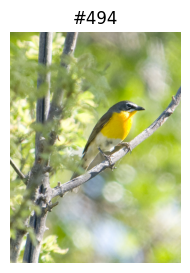

#489  class=19  img_path=datasets/CUB/CUB_200_2011/CUB_200_2011/images/020.Yellow_breasted_Chat/Yellow_Breasted_Chat_0063_21783.jpg


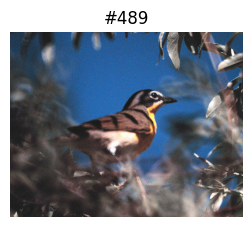

{'id': 1062,
 'img_path': 'datasets/CUB/CUB_200_2011/CUB_200_2011/images/020.Yellow_breasted_Chat/Yellow_Breasted_Chat_0063_21783.jpg',
 'class_label': 19,
 'attribute_label': [np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0)],
 'attribute_certainty': [3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
 

In [33]:
import pickle
from datasets.CUB_dataset import CUB_DatasetGenerator, get_CUB_transforms
from PIL import Image

# Local config namespace (this repo's data_defaults.yaml -> data_path='datasets/'),
# not the cluster path baked into this run's log.txt.
class _DataCfg:
    data_path = "datasets/"
    dataset = "CUB"
    pkl_file_dir = "yellow_experiment_local_1/"  # from log.txt: data.pkl_file_dir

def load_split_imgs(split_name, cfg=_DataCfg):
    """Load one split's pkl with img_path already rewritten to a real file path,
    in the exact row order the analysis loader used (shuffle=False, no reordering)."""
    pkl_path = os.path.join(cfg.data_path, "CUB", "incomplete_data", cfg.pkl_file_dir, f"{split_name}.pkl")
    with open(pkl_path, "rb") as f:
        imgs = pickle.load(f)
    for d in imgs:
        parts = d["img_path"].split("/")
        end_path = "/".join(parts[parts.index("images"):])
        d["img_path"] = os.path.join(cfg.data_path, "CUB/CUB_200_2011/CUB_200_2011/", end_path)
    return imgs

test_imgs = load_split_imgs("test")
_, test_transform = get_CUB_transforms(resol=299)
test_dataset = CUB_DatasetGenerator(test_imgs, transform=test_transform, cache=False)

def show_sample(row):
    """row = the index used in plot titles ('#501'), i.e. position in test/*.pt tensors."""
    meta = test_imgs[row]
    print(f"#{row}  class={meta['class_label']}  img_path={meta['img_path']}")
    img = Image.open(meta["img_path"]).convert("RGB")
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(f"#{row}")
    plt.axis("off")
    plt.show()
    return meta

# e.g.
show_sample(494)
show_sample(489)



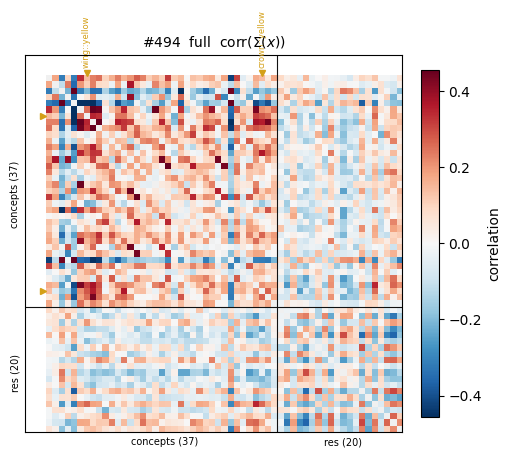

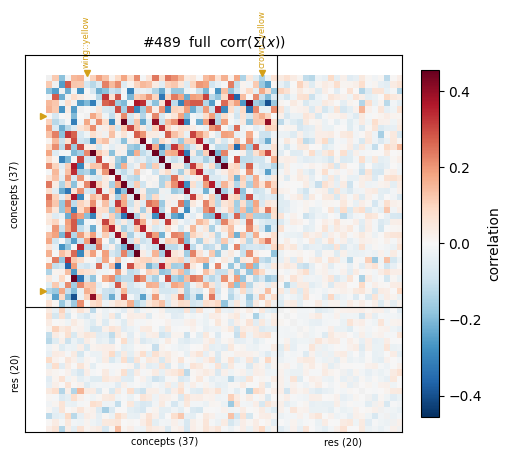

In [34]:
cov_full = torch.load(f"{RUN}/test/covariance_matrices.pt", map_location="cpu").float().numpy()

concept_names = [kept_attr_names[i] for i in range(N_C)]
residual_names = [f"res_{i}" for i in range(N_R)]
axis_names = concept_names + residual_names

def get_covariance(row, corr=False, block="full"):
    """row = absolute index into test/*.pt tensors (matches the '#row' plot labels).
    block: 'full', 'cc' (concept-concept), 'rr' (residual-residual), 'cr' (concept-residual cross)."""
    M = cov_full[row].copy()
    if corr:
        d = np.sqrt(np.diag(M))
        M = M / np.outer(d, d)

    sl = {"full": (slice(None), slice(None)),
          "cc": (slice(0, N_C), slice(0, N_C)),
          "rr": (slice(N_C, None), slice(N_C, None)),
          "cr": (slice(0, N_C), slice(N_C, None))}[block]
    row_names = axis_names[sl[0]] if block != "cr" else concept_names
    col_names = axis_names[sl[1]] if block != "cr" else residual_names
    return pd.DataFrame(M[sl], index=row_names, columns=col_names)




def plot_covariance(row, corr=True, block="full", ax=None, vlim=None):
    """Single-sample heatmap, styled like the class-grid plots above."""
    M = get_covariance(row, corr=corr, block=block).to_numpy()

    if block == "full":
        M_show = no_diag(M) if corr else M
        cm, default_v = (cmap, vc) if corr else ("RdBu_r", v)
    else:
        # cross block ('cr') has no diagonal to blank; cc/rr do but they're
        # small enough that a local scale (not the class-wide vc/v) reads better.
        M_show = M if block == "cr" else (no_diag(M) if corr else M)
        cm = cmap if corr else "RdBu_r"
        default_v = np.percentile(np.abs(M[~np.isnan(M)]), 99.5) if vlim is None else None

    vv = vlim if vlim is not None else default_v

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 4.6), constrained_layout=True)
    im = ax.imshow(M_show, cmap=cm, vmin=-vv, vmax=vv, interpolation="nearest")

    if block == "full":
        blocks(ax, names=True)
    else:
        ax.set_xticks(range(M.shape[1])); ax.set_yticks(range(M.shape[0]))
        ax.set_xticklabels(M.shape[1] * [""] if M.shape[1] > 12 else
                            get_covariance(row, corr, block).columns, rotation=90, fontsize=6)
        ax.set_yticklabels(M.shape[0] * [""] if M.shape[0] > 20 else
                            get_covariance(row, corr, block).index, fontsize=6)

    if standalone:
        ax.set_title(f"#{row}  {block}  {'corr' if corr else 'cov'}($\\Sigma(x)$)", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=.046, label="correlation" if corr else "covariance")
        plt.show()
    return im



# a small multiple grid over arbitrary rows (e.g. rows list, or any list you pick)
def plot_covariance_grid(row_list, corr=True, block="full", ncol=6):
    n = len(row_list)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(1.65 * ncol, 1.65 * nrow), constrained_layout=True)
    for i, ax in enumerate(np.atleast_1d(axes).ravel()):
        if i >= n:
            ax.axis("off"); continue
        plot_covariance(row_list[i], corr=corr, block=block, ax=ax)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"#{row_list[i]}", fontsize=6)
    fig.suptitle(f"{block}  {'corr' if corr else 'cov'}($\\Sigma(x)$) for {n} samples", fontsize=10)
    plt.show()





# single sample, full matrix, correlation
plot_covariance(494, corr=True, block="full")


# single sample, full matrix, correlation
plot_covariance(489, corr=True, block="full")

In [37]:
from datasets.CUB_dataset import ATTRIBUTES_IDX_USED   # 112 0-based indices into the 312 space

CERTAINTY_WORDS = {1: "not visible", 2: "guessing", 3: "probably", 4: "definitely"}


def _img_key(p):
    """<class_folder>/<file>.jpg -- unique within a split, and invariant to the
    img_path rewriting (cluster path vs local path) that the loader applies."""
    return "/".join(p.split("/")[-2:])


_full_cache, _inc_cache = {}, {}

def _full_split(split, cfg=_DataCfg):
    """ORIGINAL complete-attribute pkl, keyed by image: 112 labels + 312 certainties."""
    if split not in _full_cache:
        with open(os.path.join(cfg.data_path, "CUB", "class_attr_data_10", f"{split}.pkl"), "rb") as f:
            entries = pickle.load(f)
        by_key = {_img_key(e["img_path"]): e for e in entries}
        assert len(by_key) == len(entries), "img_path key collision"
        _full_cache[split] = by_key
    return _full_cache[split]

def _inc_split(split, cfg=_DataCfg):
    """This run's INCOMPLETE pkl, in loader/row order (row i == row i of test/*.pt)."""
    if split not in _inc_cache:
        _inc_cache[split] = load_split_imgs(split, cfg)
    return _inc_cache[split]


def sample_attributes(row, split="test", only="all", cfg=_DataCfg):
    """Full 112-concept label + per-sample annotator certainty for one row.

    row   : index into <split>/*.pt (the '#row' in the plot titles)
    only  : 'all' | 'hidden' (dropped by the incomplete split) | 'kept'
    """
    meta = _inc_split(split, cfg)[row]
    full = _full_split(split, cfg)[_img_key(meta["img_path"])]
    assert full["class_label"] == meta["class_label"], "class mismatch -- wrong split?"

    cert = np.asarray(full["attribute_certainty"])[ATTRIBUTES_IDX_USED]   # 312 -> 112
    lab = np.asarray(full["attribute_label"], dtype=int)                  # already 112

    df = pd.DataFrame({
        "old_idx": np.arange(112),
        "attribute": [attr_idx_to_names[i] for i in range(112)],
        "label": lab,
        "certainty": cert,
        "certainty_word": [CERTAINTY_WORDS[c] for c in cert],
        "new_idx": [attr_idx_mapping_dict.get(i, -1) for i in range(112)],
    })
    df["kept"] = df["new_idx"] >= 0
    df.attrs.update(row=row, split=split, img_path=meta["img_path"],
                    class_label=full["class_label"], id=full["id"])

    if only == "hidden":
        df = df[~df["kept"]]
    elif only == "kept":
        df = df.sort_values("new_idx")[lambda d: d["kept"]]
    return df.reset_index(drop=True)


def print_sample_attributes(row, split="test", only="all", positive_only=False):
    df = sample_attributes(row, split=split, only=only)
    a = df.attrs
    print(f"#{row} [{split}]  id={a['id']}  class={a['class_label']}\n{a['img_path']}")
    print(f"{len(df)} attributes ({only}), mean certainty {df['certainty'].mean():.2f}, "
          f"{(df['certainty'] == 1).sum()} not visible")
    display(df[df["label"] == 1] if positive_only else df)
    return df


# e.g. the hidden (dropped) concepts for sample #501, with how sure the annotator was
#print_sample_attributes(501, only="hidden")

# only the yellow attributes for that sample
d_494 = sample_attributes(494)
display(d_494[d_494["attribute"].str.contains("yellow")])

d_489 = sample_attributes(489)
display(d_489[d_489["attribute"].str.contains("yellow")])


/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_35544/325218879.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entries = pickle.load(f)


,old_idx,attribute,label,certainty,certainty_word,new_idx,kept
6,6,has_wing_color::yellow,0,4,definitely,6,True
12,12,has_upperparts_color::yellow,0,4,definitely,-1,False
18,18,has_underparts_color::yellow,1,4,definitely,-1,False
27,27,has_back_color::yellow,0,3,probably,-1,False
41,41,has_breast_color::yellow,1,4,definitely,-1,False
46,46,has_throat_color::yellow,1,4,definitely,-1,False
56,56,has_forehead_color::yellow,0,4,definitely,-1,False
66,66,has_nape_color::yellow,0,4,definitely,-1,False
72,72,has_belly_color::yellow,1,4,definitely,-1,False
92,92,has_primary_color::yellow,1,4,definitely,-1,False


,old_idx,attribute,label,certainty,certainty_word,new_idx,kept
6,6,has_wing_color::yellow,0,4,definitely,6,True
12,12,has_upperparts_color::yellow,0,4,definitely,-1,False
18,18,has_underparts_color::yellow,1,4,definitely,-1,False
27,27,has_back_color::yellow,0,4,definitely,-1,False
41,41,has_breast_color::yellow,1,4,definitely,-1,False
46,46,has_throat_color::yellow,1,4,definitely,-1,False
56,56,has_forehead_color::yellow,0,3,probably,-1,False
66,66,has_nape_color::yellow,0,4,definitely,-1,False
72,72,has_belly_color::yellow,1,4,definitely,-1,False
92,92,has_primary_color::yellow,1,4,definitely,-1,False


In [42]:
# ---- per-sample predictions -------------------------------------------------
# Semantics of the saved tensors (scbm_residual, concept_learning='hard', M=100):
#   c_res_mu                        mu(x), mean of the joint Gaussian over [concept logits | residual]
#   concepts_residuals_logits_*     MC mean/std of eta ~ N(mu, Sigma(x))
#                                     mean ~= c_res_mu,  std ~= sqrt(diag Sigma(x))
#   concepts_residuals_pred_probs_* MC mean/std of sigmoid(eta). The mean is the concept
#                                     probability the model actually reports -- E[sigma(eta)],
#                                     which is NOT sigma(mu); the std is its stochastic spread.
#   concepts_residuals_sample_mean  MC mean of the *hard* Bernoulli draws -- literally what the
#                                     task head averaged over (hard mode feeds it binary [C+R])
#   y_pred                          log(mean_m softmax(head(...))) -> exp() gives probabilities
PRED_FILES = ["c_res_mu", "concepts_residuals_logits_mean", "concepts_residuals_logits_std",
              "concepts_residuals_pred_probs_mean", "concepts_residuals_pred_probs_std",
              "concepts_residuals_sample_mean", "concepts_residuals_sample_std",
              "y_pred", "y_true"]

def load_preds(split="test", run=RUN):
    P = {f: torch.load(f"{run}/{split}/{f}.pt", map_location="cpu").float().numpy()
         for f in PRED_FILES}
    
    P["cov"] = torch.load(f"{run}/{split}/covariance_matrices.pt", map_location="cpu").float().numpy()
    return P

_pred_cache = {}
def _preds(split="test"):
    if split not in _pred_cache:
        _pred_cache[split] = load_preds(split)
    return _pred_cache[split]


def predicted_concepts(row, split="test", with_certainty=True, sort_by=None):
    """Per-concept prediction vs. ground truth for one sample (the 37 surviving concepts)."""
    P = _preds(split)
    c = slice(0, N_C)
    truth = np.asarray(_inc_split(split)[row]["attribute_label"], dtype=int)   # 37-dim, class-level

    df = pd.DataFrame({
        "new_idx": np.arange(N_C),
        "concept": concept_names,
        "true": truth,
        "prob": P["concepts_residuals_pred_probs_mean"][row, c],   # E[sigma(eta)]
        "prob_std": P["concepts_residuals_pred_probs_std"][row, c],
        "mu": P["c_res_mu"][row, c],                               # logit mean
        "sd_eta": np.sqrt(np.diag(P["cov"][row]))[c],              # sqrt(diag Sigma(x))
        "hard_rate": P["concepts_residuals_sample_mean"][row, c],  # what the head averaged over
    })
    df["pred"] = (df["prob"] >= 0.5).astype(int)
    df["correct"] = df["pred"] == df["true"]

    if with_certainty:
        old = {new: old for old, new in attr_idx_mapping_dict.items()}
        cert = sample_attributes(row, split=split).set_index("old_idx")
        df["old_idx"] = df["new_idx"].map(old)
        df["certainty"] = df["old_idx"].map(cert["certainty"])       # annotator, 1-4
        df["certainty_word"] = df["old_idx"].map(cert["certainty_word"])

    if sort_by:
        df = df.sort_values(sort_by, ascending=False)
    return df.reset_index(drop=True)


def predicted_residuals(row, split="test"):
    P = _preds(split)
    r = slice(N_C, None)
    return pd.DataFrame({
        "res_idx": np.arange(N_R),
        "mu": P["c_res_mu"][row, r],
        "sd_eta": np.sqrt(np.diag(P["cov"][row]))[r],
        "prob": P["concepts_residuals_pred_probs_mean"][row, r],   # sigmoid squashing only
        "hard_rate": P["concepts_residuals_sample_mean"][row, r],  # binarised -> head input
    })


def print_prediction(row, split="test", top_k=5, only_wrong=False, show_residuals=True, show_concepts=True):
    P = _preds(split)
    meta = _inc_split(split)[row]
    logp = P["y_pred"][row]
    probs = np.exp(logp)
    order = np.argsort(-probs)[:top_k]
    y_true = int(P["y_true"][row])

    print(f"#{row} [{split}]  {os.path.basename(meta['img_path'])}")
    print(f"true class {y_true}"
          + (f" ({class_id_to_name[y_true]})" if "class_id_to_name" in globals() else "")
          + f"   predicted {order[0]}  p={probs[order[0]]:.3f}"
          f"   {'CORRECT' if order[0] == y_true else 'WRONG'}"
          f"   rank of true class = {int(np.where(np.argsort(-probs) == y_true)[0][0]) + 1}")
    print("top-k: " + ", ".join(f"{k}:{probs[k]:.3f}" for k in order))

    df = predicted_concepts(row, split=split)
    print(f"\nconcepts: {df['correct'].sum()}/{N_C} correct "
          f"({df['correct'].mean():.3f}), mean prob_std {df['prob_std'].mean():.3f}")
    if show_concepts:
        display(df[~df["correct"]] if only_wrong else df)

    if show_residuals:
        print("residual channel:")
        display(predicted_residuals(row, split=split))
    return df

def concepts_matching(row, pattern, split="test", **kw):
    df = predicted_concepts(row, split=split, **kw)
    return df[df["concept"].str.contains(pattern, case=False)].sort_values("prob", ascending=False)




print_prediction(489, show_residuals=False, show_concepts=False)
display(concepts_matching(489, "yellow", sort_by="prob").head(10))   # most confidently-on concepts
#predicted_concepts(489, sort_by="prob").head(10)   # most confidently-on concepts


print_prediction(494, show_residuals=False, show_concepts=False)
display(concepts_matching(494, "yellow", sort_by="prob").head(10)) 

#489 [test]  Yellow_Breasted_Chat_0063_21783.jpg
true class 19 (020.Yellow_breasted_Chat)   predicted 192  p=0.053   WRONG   rank of true class = 4
top-k: 192:0.053, 177:0.033, 194:0.025, 19:0.024, 167:0.023

concepts: 34/37 correct (0.919), mean prob_std 0.087


,new_idx,concept,true,prob,prob_std,mu,sd_eta,hard_rate,pred,correct,old_idx,certainty,certainty_word
20,6,has_wing_color::yellow,0,0.045899,0.046383,-3.301356,1.072033,0.04,0,True,6,4,definitely
28,34,has_crown_color::yellow,0,0.035127,0.042431,-3.809183,1.081128,0.04,0,True,105,4,definitely


#494 [test]  Yellow_Breasted_Chat_0023_21664.jpg
true class 19 (020.Yellow_breasted_Chat)   predicted 19  p=0.698   CORRECT   rank of true class = 1
top-k: 19:0.698, 127:0.064, 173:0.024, 73:0.017, 162:0.011

concepts: 37/37 correct (1.000), mean prob_std 0.000


,new_idx,concept,true,prob,prob_std,mu,sd_eta,hard_rate,pred,correct,old_idx,certainty,certainty_word
27,6,has_wing_color::yellow,0,0.000003,0.000017,-16.053795,2.501725,0.0,0,True,6,4,definitely
29,34,has_crown_color::yellow,0,0.000003,0.000020,-17.878952,2.965145,0.0,0,True,105,4,definitely
